# Within-Cycle SOH Estimation → RUL (Micro-Clock DL) — `06_train_dl.ipynb`

**The payoff.** Notebooks 03 and 04 worked on the *macro clock*: one timestep = one whole cycle,
scalar features only.  The RF baseline was very strong (MAE 0.032, R² 0.966) — too strong for
macro-clock DL to beat on 13 trajectories.  The gap was the signal: the baselines reduced each
charge curve to scalars and threw away the **curve shape**.

This notebook changes the clock:

```
raw .mat charge curve  ──(nb05)──►  (128, 3) tensor [V, I, T]
                                          │  train
                                          ▼
                           CNN / TCN / LSTM  (this notebook)
                                          │
                                          ▼
                    per-cycle SOH estimate  (capacity_retention)
                                          │  threshold extrapolation
                                          ▼
                           RUL  ──►  compare to RF baseline 0.032
```

With **~780 samples** (vs 13 trajectories) and the **curve shape** the baselines never accessed,
DL is expected to earn its place here.

## 1. Imports & setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from sequence    import LSTMReg, train_model, predict_model
from curve_models import (
    CNNReg, TCNRegPooled, LSTMRegPooled, GRURegPooled, TransformerReg,
    per_sample_scale, jitter,
)

sns.set_theme(style='darkgrid', palette='tab10')
np.random.seed(42)
torch.manual_seed(42)

device = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()           else
    torch.device('cpu')
)
print(f'device: {device}')

PROCESSED = ROOT / 'data' / 'processed'
RESULTS   = ROOT / 'results'
MODELS    = ROOT / 'models'
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

device: mps


## 2. Load tensor dataset

In [2]:
data = np.load(PROCESSED / "charge_curves.npz", allow_pickle=True)

X          = data["X"].astype(np.float32)         # (n, 128, 3)
soh        = data["soh"].astype(np.float32)        # capacity_retention, 0-1
cap_ahr    = data["cap_ahr"].astype(np.float32)
rul_frac   = data["rul_frac"].astype(np.float32)
eol_index  = data["eol_index"].astype(np.float32)
battery_id = data["battery_id"]
cycle_idx  = data["cycle_index"].astype(np.int32)
split      = data["split"]
scalars    = data["scalars"].astype(np.float32)   # [r_proxy, voltage_mean, temp_mean, temp_max, duration_s]

SCALAR_COLS = ["r_proxy", "voltage_mean", "temp_mean", "temp_max", "duration_s"]
N, C = X.shape[1], X.shape[2]
all_bids = sorted(np.unique(battery_id))
mask = np.ones((len(X), N), dtype=bool)  # full mask — no padding, curves are fixed length

print(f"X: {X.shape}  soh: {soh.shape}")
print(f"Batteries: {all_bids}")
print(f"Train: {(split=='train').sum()}  Test: {(split=='test').sum()}")

X: (788, 128, 3)  soh: (788,)
Batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20', 'RW9']
Train: 577  Test: 211


## 3. Model zoo & param counts

In [3]:
# ---------------------------------------------------------------------------
# Harness constants -- held identical across all architectures
# ---------------------------------------------------------------------------
# L1 loss, cosine LR, Adam lr=3e-4, grad clip 1.0 -- all in train_model
# dropout=0.25 on FC head (default; matches conv-block dropout in CNN/TCN).
# Testing showed no effect but this keeps the comparison symmetric.
# Conv-block internal dropout (0.25) is architectural, not a tuning choice.
# ---------------------------------------------------------------------------

ARCH_MAP = {
    'CNN':         lambda: CNNReg(C, dropout=0.25).to(device),
    'TCN':         lambda: TCNRegPooled(C, dropout=0.25, n_channels=48).to(device),
    #'GRU':         lambda: GRURegPooled(C, hidden=64, dropout=0.25).to(devuice),  
    # GRU removed because it is very slow on macos mps for some reason
    'LSTM':        lambda: LSTMRegPooled(C, hidden=64, dropout=0.25).to(device),
    'Transformer': lambda: TransformerReg(C, dropout=0.25).to(device),
}

# Hybrid variants: same backbone + 9 charge scalars at the head
N_SC = 9

ARCH_MAP_HYBRID = {
    'Hybrid-LSTM': lambda: LSTMRegPooled(C, hidden=64, dropout=0.25, n_scalars=N_SC).to(device),
    'Hybrid-CNN':  lambda: CNNReg(C, dropout=0.25, n_scalars=N_SC).to(device),
    'Hybrid-TCN':  lambda: TCNRegPooled(C, dropout=0.25, n_scalars=N_SC).to(device),
}

# Single LR for all architectures
LR_MAP = {a: 3e-4 for a in {**ARCH_MAP, **ARCH_MAP_HYBRID}}

print(f"{'Model':<16}  {'Params':>8}  {'LR':>8}")
print('-' * 38)
for name, factory in {**ARCH_MAP, **ARCH_MAP_HYBRID}.items():
    m = factory()
    n = sum(p.numel() for p in m.parameters())
    print(f'{name:<16}  {n:>8,}  {LR_MAP[name]:.0e}')

CONTROLLED_BIDS = ['B0005', 'B0006', 'B0007', 'B0018']
SIGMA_JITTER   = 0.005

def make_jitter_fn(sigma: float = SIGMA_JITTER):
    def fn(xb: torch.Tensor) -> torch.Tensor:
        return jitter(xb, sigma=sigma)
    return fn

Model               Params        LR
--------------------------------------
CNN                 23,745  3e-04
TCN                 36,241  3e-04
LSTM                35,713  3e-04
Transformer         21,377  3e-04
Hybrid-LSTM         35,722  3e-04
Hybrid-CNN          23,754  3e-04
Hybrid-TCN          36,250  3e-04


/Users/benji/dev/efrei/ml-project/src/curve_models.py:372: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)


## 4. Charge-scalar RF baseline (fair comparison)

Both the RF and the DL models receive the **same input**: the 3-channel (V, I, T) charge window.
The difference is representation only:

```
RF   — 9 hand-crafted scalars derived from X  (summaries: means, stds, slopes)
DL   — the raw 128-point curve fed to a neural network
```

The question is whether the **curve shape** carries information beyond what 9 simple summaries
already capture.

> **Why not use the CSV scalars?**  `r_proxy`, `voltage_mean`, etc. are computed from the
> **discharge** cycle — the same event that generates the SOH label.  That RF is not predicting
> health from the charge; it is predicting discharge capacity from discharge features, which is
> trivially easy (Spearman ρ ≈ 0.99).  It is not a meaningful baseline for this task.

In [4]:
import warnings
from scipy.stats import ConstantInputWarning


def monotonicity_rate(y_pred):
    if len(y_pred) < 2:
        return float("nan")
    return float((np.diff(y_pred) <= 0).mean())


def lobo_metrics(y_te, y_pred, cidx_te, train_mean, eol=None):
    mae       = mean_absolute_error(y_te, y_pred)
    naive_mae = mean_absolute_error(y_te, np.full(len(y_te), train_mean))
    order     = np.argsort(cidx_te)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConstantInputWarning)
        spearman_val = float(spearmanr(y_te, y_pred).statistic)
    fold = {
        "mae":          mae,
        "rmse":         float(np.sqrt(mean_squared_error(y_te, y_pred))),
        "r2":           r2_score(y_te, y_pred),
        "naive_mae":    naive_mae,
        "skill":        float(1 - mae / naive_mae) if naive_mae > 0 else float("nan"),
        "spearman":     spearman_val,
        "monotonicity": monotonicity_rate(y_pred[order]),
        "y_true_arr":   y_te,
        "y_pred_arr":   y_pred,
        "cidx_arr":     cidx_te,
    }
    if eol is not None:
        fold["cap_mae_ahr"] = mean_absolute_error(y_te * eol, y_pred * eol)
    return fold


def aggregate(fold_results):
    summary = {}
    for key in ["mae", "rmse", "r2", "naive_mae", "skill",
                "spearman", "monotonicity", "cap_mae_ahr"]:
        vals = [f[key] for f in fold_results if key in f and not np.isnan(f[key])]
        if vals:
            summary[key]          = float(np.mean(vals))
            summary[f"{key}_std"] = float(np.std(vals))
    summary["per_fold"] = fold_results
    return summary


def oof_from_lobo(lobo_result):
    rows = []
    for fold in lobo_result["per_fold"]:
        bid = fold.get("battery", "?")
        for i in range(len(fold["y_true_arr"])):
            rows.append({"battery_id": bid,
                         "cycle_index": fold["cidx_arr"][i],
                         "y_true":      fold["y_true_arr"][i],
                         "y_pred":      fold["y_pred_arr"][i]})
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Charge-curve scalars — computed from X tensor (same input as DL)
# ---------------------------------------------------------------------------

def charge_scalars(X_arr):
    """Compute 9 hand-crafted scalars from X (n, N, C) -> (n, 9)."""
    V, I, T = X_arr[:, :, 0], X_arr[:, :, 1], X_arr[:, :, 2]
    return np.stack([
        V.mean(axis=1),
        I.mean(axis=1),
        I.std(axis=1),
        T.mean(axis=1),
        T.max(axis=1),
        T[:, -1] - T[:, 0],
        I[:, -1] - I[:, 0],
        V[:, N // 2],
        T.std(axis=1),
    ], axis=1).astype(np.float32)

CHARGE_SCALAR_COLS = [
    "V_mean", "I_mean", "I_std",
    "T_mean", "T_max", "T_rise",
    "I_droop", "V_mid", "T_std",
]

charge_sc = charge_scalars(X)
print(f"Charge scalars shape: {charge_sc.shape}")
print("Feature means:", {k: round(float(v), 3)
                         for k, v in zip(CHARGE_SCALAR_COLS, charge_sc.mean(axis=0))})

# RF on charge-curve scalars (LOBO)
rf_folds = []
for held_out in all_bids:
    is_test  = battery_id == held_out
    is_train = ~is_test
    scaler = StandardScaler().fit(charge_sc[is_train])
    X_tr = scaler.transform(charge_sc[is_train])
    X_te = scaler.transform(charge_sc[is_test])
    y_tr = soh[is_train]
    y_te = soh[is_test]
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te).clip(0, 1)
    fold = lobo_metrics(y_te, y_pred, cycle_idx[is_test], y_tr.mean())
    fold["battery"] = held_out
    rf_folds.append(fold)

rf_soh = aggregate(rf_folds)
res = rf_soh
print(f"\nRF (charge scalars) SOH LOBO:")
print(f"  MAE={res['mae']:.4f}±{res['mae_std']:.4f}  "
      f"RMSE={res['rmse']:.4f}  R²={res['r2']:.3f}±{res['r2_std']:.3f}  "
      f"skill={res['skill']:.3f}  mono={res['monotonicity']:.3f}")

Charge scalars shape: (788, 9)
Feature means: {'V_mean': 4.202, 'I_mean': 0.394, 'I_std': 0.45, 'T_mean': 25.499, 'T_max': 28.933, 'T_rise': -3.652, 'I_droop': -1.56, 'V_mid': 4.204, 'T_std': 1.64}

RF (charge scalars) SOH LOBO:
  MAE=0.0670±0.0509  RMSE=0.0818  R²=0.379±0.713  skill=0.467  mono=0.662


### Per-fold breakdown — where does the variance come from?

RF MAE std ≈ mean (std > 0.04), which is suspicious.  Plot per-fold to see if one
or two batteries are outliers vs a globally weak model.

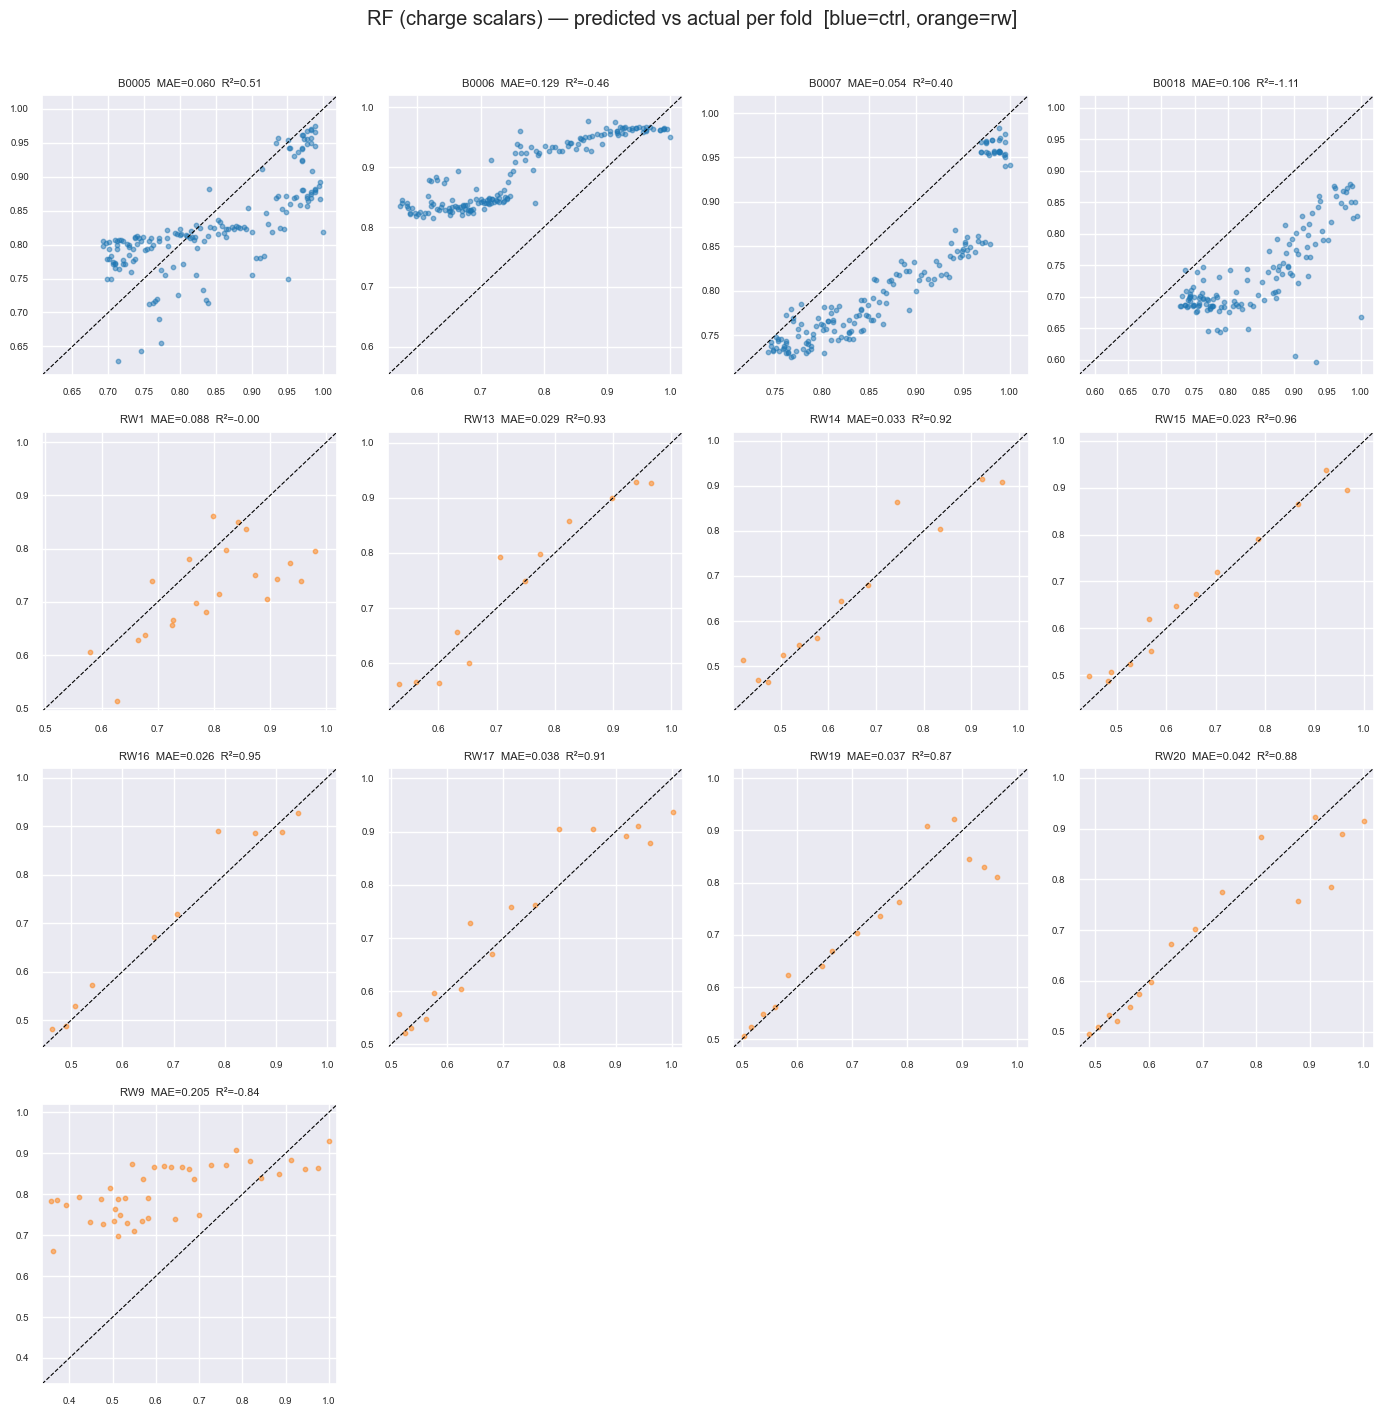

Battery         MAE      R²     n
--------------------------------------
  RW9        0.2052  -0.840    40  rw
  B0006      0.1290  -0.464   167  ctrl
  B0018      0.1064  -1.110   132  ctrl
  RW1        0.0880  -0.001    21  rw
  B0005      0.0600   0.509   167  ctrl
  B0007      0.0543   0.402   167  ctrl
  RW20       0.0419   0.878    16  rw
  RW17       0.0383   0.909    16  rw
  RW19       0.0365   0.866    15  rw
  RW14       0.0330   0.924    12  rw
  RW13       0.0287   0.931    12  rw
  RW16       0.0265   0.953    10  rw
  RW15       0.0235   0.964    13  rw


In [5]:
_CTRL_BIDS = ["B0005", "B0006", "B0007", "B0018"]
_n_bids = len(rf_folds)
_ncols  = min(4, _n_bids)
_nrows  = (_n_bids + _ncols - 1) // _ncols

fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.5 * _ncols, 3.5 * _nrows))
axes = axes.flatten()

for i, fold in enumerate(sorted(rf_folds, key=lambda f: f["battery"])):
    ax = axes[i]
    color = "tab:blue" if fold["battery"] in _CTRL_BIDS else "tab:orange"
    ax.scatter(fold["y_true_arr"], fold["y_pred_arr"], s=10, alpha=0.5, color=color)
    mn_v = min(fold["y_true_arr"].min(), fold["y_pred_arr"].min()) - 0.02
    ax.plot([mn_v, 1.02], [mn_v, 1.02], "k--", lw=0.8)
    ax.set_xlim(mn_v, 1.02); ax.set_ylim(mn_v, 1.02)
    ax.set_title(f"{fold['battery']}  MAE={fold['mae']:.3f}  R²={fold['r2']:.2f}", fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("RF (charge scalars) — predicted vs actual per fold  [blue=ctrl, orange=rw]", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "rf_scalar_per_fold.png", dpi=120)
plt.show()

print(f"{'Battery':<10} {'MAE':>8} {'R²':>7} {'n':>5}")
print("-" * 38)
for fold in sorted(rf_folds, key=lambda f: -f["mae"]):
    typ = "ctrl" if fold["battery"] in _CTRL_BIDS else "rw"
    print(f"  {fold['battery']:<8} {fold['mae']:>8.4f} {fold['r2']:>7.3f} {len(fold['y_true_arr']):>5}  {typ}")

## 5. Tier-1 sweep — architecture × epoch budget

Fixed train/test split from nb05 (whole-battery `split` column).  Val battery = last
alphabetically among training batteries.  Sweep to pick epoch budget per arch.

In [6]:
TIER1_EPOCHS   = 300
TIER1_PATIENCE = 50
BATCH_SIZE     = 32

is_test_fixed  = split == "test"
is_train_fixed = split == "train"
train_bids_fixed = sorted(np.unique(battery_id[is_train_fixed]))

avail_ctrl_t1 = [b for b in CONTROLLED_BIDS if b in train_bids_fixed]
val_bid_t1    = sorted(avail_ctrl_t1)[-1]   # B0018
is_val_fixed  = battery_id == val_bid_t1
is_inner_fixed = is_train_fixed & ~is_val_fixed

print(f"Tier-1 split: inner={sorted(np.unique(battery_id[is_inner_fixed]))}")
print(f"              val  ={val_bid_t1}")
print(f"              test ={sorted(np.unique(battery_id[is_test_fixed]))}")


X_inner_scaled = per_sample_scale(X[is_inner_fixed])
X_val_scaled   = per_sample_scale(X[is_val_fixed])

mask_inner = mask[is_inner_fixed]
mask_val   = mask[is_val_fixed]
y_inner    = soh[is_inner_fixed]
y_val_t1   = soh[is_val_fixed]

def run_tier1(arch_name):
    torch.manual_seed(42)
    model = ARCH_MAP[arch_name]()
    model, tr_c, va_c, ep = train_model(
        model, X_inner_scaled, mask_inner, y_inner,
        X_val_scaled, mask_val, y_val_t1,
        device,
        epochs=TIER1_EPOCHS,
        patience=TIER1_PATIENCE,
        lr=LR_MAP.get(arch_name, 3e-4),
        scheduler="cosine",
        augment_fn=make_jitter_fn(SIGMA_JITTER),
        batch_size=BATCH_SIZE,
    )
    return ep, tr_c, va_c

tier1_results = {}
for arch in ARCH_MAP:
    if arch == "GRU":
        print(f"Skipping {arch} for Tier-1 due to poor steps/sec on macos (10x slower than LSTM and Transformer).")
        continue
    ep, tr_c, va_c = run_tier1(arch)
    tier1_results[arch] = {"best_ep": ep, "train_curve": tr_c, "val_curve": va_c}
    print(f"{arch}: best_ep={ep}, final_val_loss={va_c[ep-1]:.5f}")

best_ep_per_arch = {arch: tier1_results[arch]["best_ep"] for arch in ARCH_MAP}
print("Epoch budgets (informational):", best_ep_per_arch)

Tier-1 split: inner=['B0005', 'B0006', 'RW1', 'RW13', 'RW14', 'RW16', 'RW17', 'RW9']
              val  =B0018
              test =['B0007', 'RW15', 'RW19', 'RW20']


  0%|                    | 0/300 [00:00<?, ?ep/s]

CNN: best_ep=1, final_val_loss=0.05879


  0%|                    | 0/300 [00:00<?, ?ep/s]

TCN: best_ep=24, final_val_loss=0.04264


  0%|                    | 0/300 [00:00<?, ?ep/s]

LSTM: best_ep=13, final_val_loss=0.04784


/Users/benji/dev/efrei/ml-project/src/curve_models.py:372: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)


  0%|                    | 0/300 [00:00<?, ?ep/s]

Transformer: best_ep=53, final_val_loss=0.06201
Epoch budgets (informational): {'CNN': 1, 'TCN': 24, 'LSTM': 13, 'Transformer': 53}


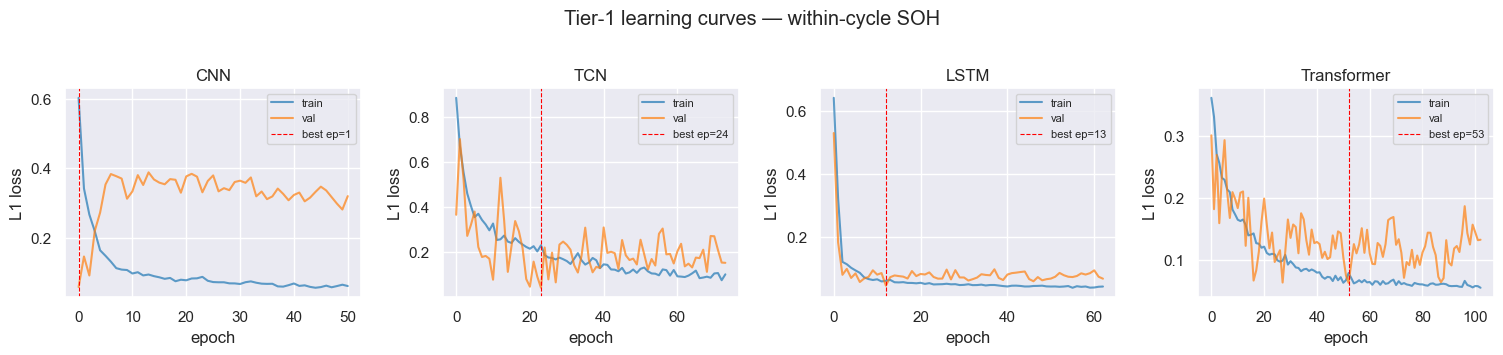

Epoch budgets: {'CNN': 1, 'TCN': 24, 'LSTM': 13, 'Transformer': 53}


In [7]:
# Learning curves
n_archs = len(ARCH_MAP)
fig, axes = plt.subplots(1, n_archs, figsize=(3.8 * n_archs, 3.5), sharey=False)
if n_archs == 1:
    axes = [axes]
for ax, arch in zip(axes, ARCH_MAP):
    r   = tier1_results[arch]
    ep  = r['best_ep']
    ax.plot(r['train_curve'], label='train', alpha=0.7)
    ax.plot(r['val_curve'],   label='val',   alpha=0.7)
    ax.axvline(ep - 1, color='red', ls='--', lw=0.8, label=f'best ep={ep}')
    ax.set_title(arch)
    ax.set_xlabel('epoch')
    ax.set_ylabel('L1 loss')
    ax.legend(fontsize=8)

plt.suptitle('Tier-1 learning curves — within-cycle SOH', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'dl_micro_learning_curves.png', dpi=120)
plt.show()

best_ep_per_arch = {arch: tier1_results[arch]['best_ep'] for arch in ARCH_MAP}
print('Epoch budgets:', best_ep_per_arch)

In [8]:
sc_scaler_t1 = StandardScaler().fit(charge_sc[is_inner_fixed])
S_inner = sc_scaler_t1.transform(charge_sc[is_inner_fixed]).astype(np.float32)
S_val_h = sc_scaler_t1.transform(charge_sc[is_val_fixed]).astype(np.float32)

def run_tier1_hybrid(arch_name):
    torch.manual_seed(42)
    model = ARCH_MAP_HYBRID[arch_name]()
    model, tr_c, va_c, ep = train_model(
        model, X_inner_scaled, mask_inner, y_inner,
        X_val_scaled, mask_val, y_val_t1,
        device,
        epochs=TIER1_EPOCHS,
        patience=TIER1_PATIENCE,
        lr=LR_MAP.get(arch_name, 3e-4),
        scheduler="cosine",
        augment_fn=make_jitter_fn(SIGMA_JITTER),
        S_tr=S_inner,
        S_val=S_val_h,
    )
    return ep, tr_c, va_c

print("Hybrid Tier-1 (curve + 9 scalars):")
for arch in ARCH_MAP_HYBRID:
    ep, tr_c, va_c = run_tier1_hybrid(arch)
    print(f"  {arch}: best_ep={ep}, final_val_loss={va_c[ep-1]:.5f}")

Hybrid Tier-1 (curve + 9 scalars):


  0%|                    | 0/300 [00:00<?, ?ep/s]

  Hybrid-LSTM: best_ep=72, final_val_loss=0.03783


  0%|                    | 0/300 [00:00<?, ?ep/s]

  Hybrid-CNN: best_ep=2, final_val_loss=0.11717


  0%|                    | 0/300 [00:00<?, ?ep/s]

  Hybrid-TCN: best_ep=35, final_val_loss=0.05745


## 6. Tier-2 LOBO — final evaluation

Per fold: one battery held out, scaler fit on all remaining batteries,
jitter applied to train only, inner early-stopping val = last alphabetical
training battery.  Same protocol as notebook 04.

In [9]:
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

N_WORKERS  = 8
BATCH_SIZE = 32
PATIENCE   = 50

_init_lock = threading.Lock()


def _run_fold(held_out, arch_name, arch_map, use_scalars, fold_seed, model):
    train_bids = [b for b in all_bids if b != held_out]
    avail_ctrl = [b for b in CONTROLLED_BIDS if b in train_bids]
    val_bid    = sorted(avail_ctrl)[-1] if avail_ctrl else sorted(train_bids)[-1]
    inner_bids = [b for b in train_bids if b != val_bid]

    is_inner = np.isin(battery_id, inner_bids)
    is_val   = battery_id == val_bid
    is_test  = battery_id == held_out

    X_in = per_sample_scale(X[is_inner])
    X_va = per_sample_scale(X[is_val])
    X_te = per_sample_scale(X[is_test])

    S_in = S_va = S_te = None
    if use_scalars:
        sc_scaler = StandardScaler().fit(charge_sc[is_inner])
        S_in = sc_scaler.transform(charge_sc[is_inner]).astype(np.float32)
        S_va = sc_scaler.transform(charge_sc[is_val]).astype(np.float32)
        S_te = sc_scaler.transform(charge_sc[is_test]).astype(np.float32)

    y_in    = soh[is_inner]
    y_va    = soh[is_val]
    y_te    = soh[is_test]
    cidx_te = cycle_idx[is_test]

    fold_gen = torch.Generator(device=device)
    fold_gen.manual_seed(fold_seed + 1000)

    train_model(
        model, X_in, mask[is_inner], y_in,
        X_va, mask[is_val], y_va,
        device,
        epochs=300,
        patience=PATIENCE,
        batch_size=BATCH_SIZE,
        lr=LR_MAP.get(arch_name, 3e-4),
        scheduler='cosine',
        weight_decay=1e-4,
        augment_fn=lambda xb: jitter(xb, sigma=SIGMA_JITTER, rng=fold_gen),
        S_tr=S_in,
        S_val=S_va,
        progress=False,
    )
    y_pred     = predict_model(model, X_te, mask[is_test], device, S=S_te)
    train_mean = np.concatenate([y_in, y_va]).mean()
    fold       = lobo_metrics(y_te, y_pred, cidx_te, train_mean, eol=cap_ahr[is_test])
    fold['battery'] = held_out
    return fold


def lobo_cv_curve(arch_name, arch_map=None, use_scalars=False) -> dict:
    if arch_map is None:
        arch_map = ARCH_MAP

    fold_models = []
    for idx, _ in enumerate(all_bids):
        with _init_lock:
            torch.manual_seed(idx * 31 + 42)
            fold_models.append(arch_map[arch_name]().to(device))

    fold_args = [
        (held_out, arch_name, arch_map, use_scalars, idx * 31 + 42, model)
        for idx, (held_out, model) in enumerate(zip(all_bids, fold_models))
    ]

    fold_results = []
    fold_bar = tqdm(total=len(all_bids), desc=f'LOBO {arch_name}', unit='fold')

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(_run_fold, *args): args[0] for args in fold_args}
        for future in as_completed(futures):
            fold = future.result()
            fold_results.append(fold)
            fold_bar.set_postfix(done=fold['battery'], mae=f"{fold['mae']:.4f}")
            fold_bar.update(1)

    fold_bar.close()
    return aggregate(fold_results)


# ---------------------------------------------------------------------------
# Models to evaluate
# Pure-curve archs go in lobo_results; Hybrid-* (curve+scalars) in lobo_results_hybrid
# ---------------------------------------------------------------------------
TO_EVAL = [
    'CNN',
    'TCN',
    'LSTM',
    'Transformer',
    'Hybrid-LSTM',
    # 'Hybrid-CNN',
    # 'Hybrid-TCN',
]

lobo_results        = {}
lobo_results_hybrid = {}

print(f'Tier-2 LOBO  (N_WORKERS={N_WORKERS}, batch={BATCH_SIZE}, patience={PATIENCE})')
print(f'Models: {TO_EVAL}\n')

for arch in TO_EVAL:
    is_hybrid  = arch in ARCH_MAP_HYBRID
    arch_map   = ARCH_MAP_HYBRID if is_hybrid else ARCH_MAP
    res = lobo_cv_curve(arch, arch_map=arch_map, use_scalars=is_hybrid)
    (lobo_results_hybrid if is_hybrid else lobo_results)[arch] = res
    print(f'  {arch}: MAE={res["mae"]:.4f}\u00b1{res["mae_std"]:.4f}  '
          f'R\u00b2={res["r2"]:.3f}\u00b1{res["r2_std"]:.3f}  '
          f'skill={res["skill"]:.3f}  mono={res["monotonicity"]:.3f}')

Tier-2 LOBO  (N_WORKERS=8, batch=32, patience=50)
Models: ['CNN', 'TCN', 'LSTM', 'Transformer', 'Hybrid-LSTM']



LOBO CNN:   0%|          | 0/13 [00:00<?, ?fold/s]

  CNN: MAE=0.1470±0.0545  R²=-0.900±2.034  skill=-0.144  mono=0.653


LOBO TCN:   0%|          | 0/13 [00:00<?, ?fold/s]

  TCN: MAE=0.1788±0.1163  R²=-3.364±6.454  skill=-0.536  mono=0.635


...

/Users/benji/dev/efrei/ml-project/src/curve_models.py:372: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)


LOBO Transformer:   0%|          | 0/13 [00:00<?, ?fold/s]

  Transformer: MAE=0.0925±0.0540  R²=0.048±1.079  skill=0.328  mono=0.604


LOBO Hybrid-LSTM:   0%|          | 0/13 [00:00<?, ?fold/s]

  Hybrid-LSTM: MAE=0.0597±0.0362  R²=0.468±0.743  skill=0.530  mono=0.714


Time:\
CNN        : 15s per fold -  3mn total\
TCN        : 20s per fold -  5mn total\
GRU        : 2mn per fold - 20mn total

note: dropped GRU because it seems to be extremely slow on mps

### Per-fold DL scatter — is the failure global or concentrated in a few batteries?

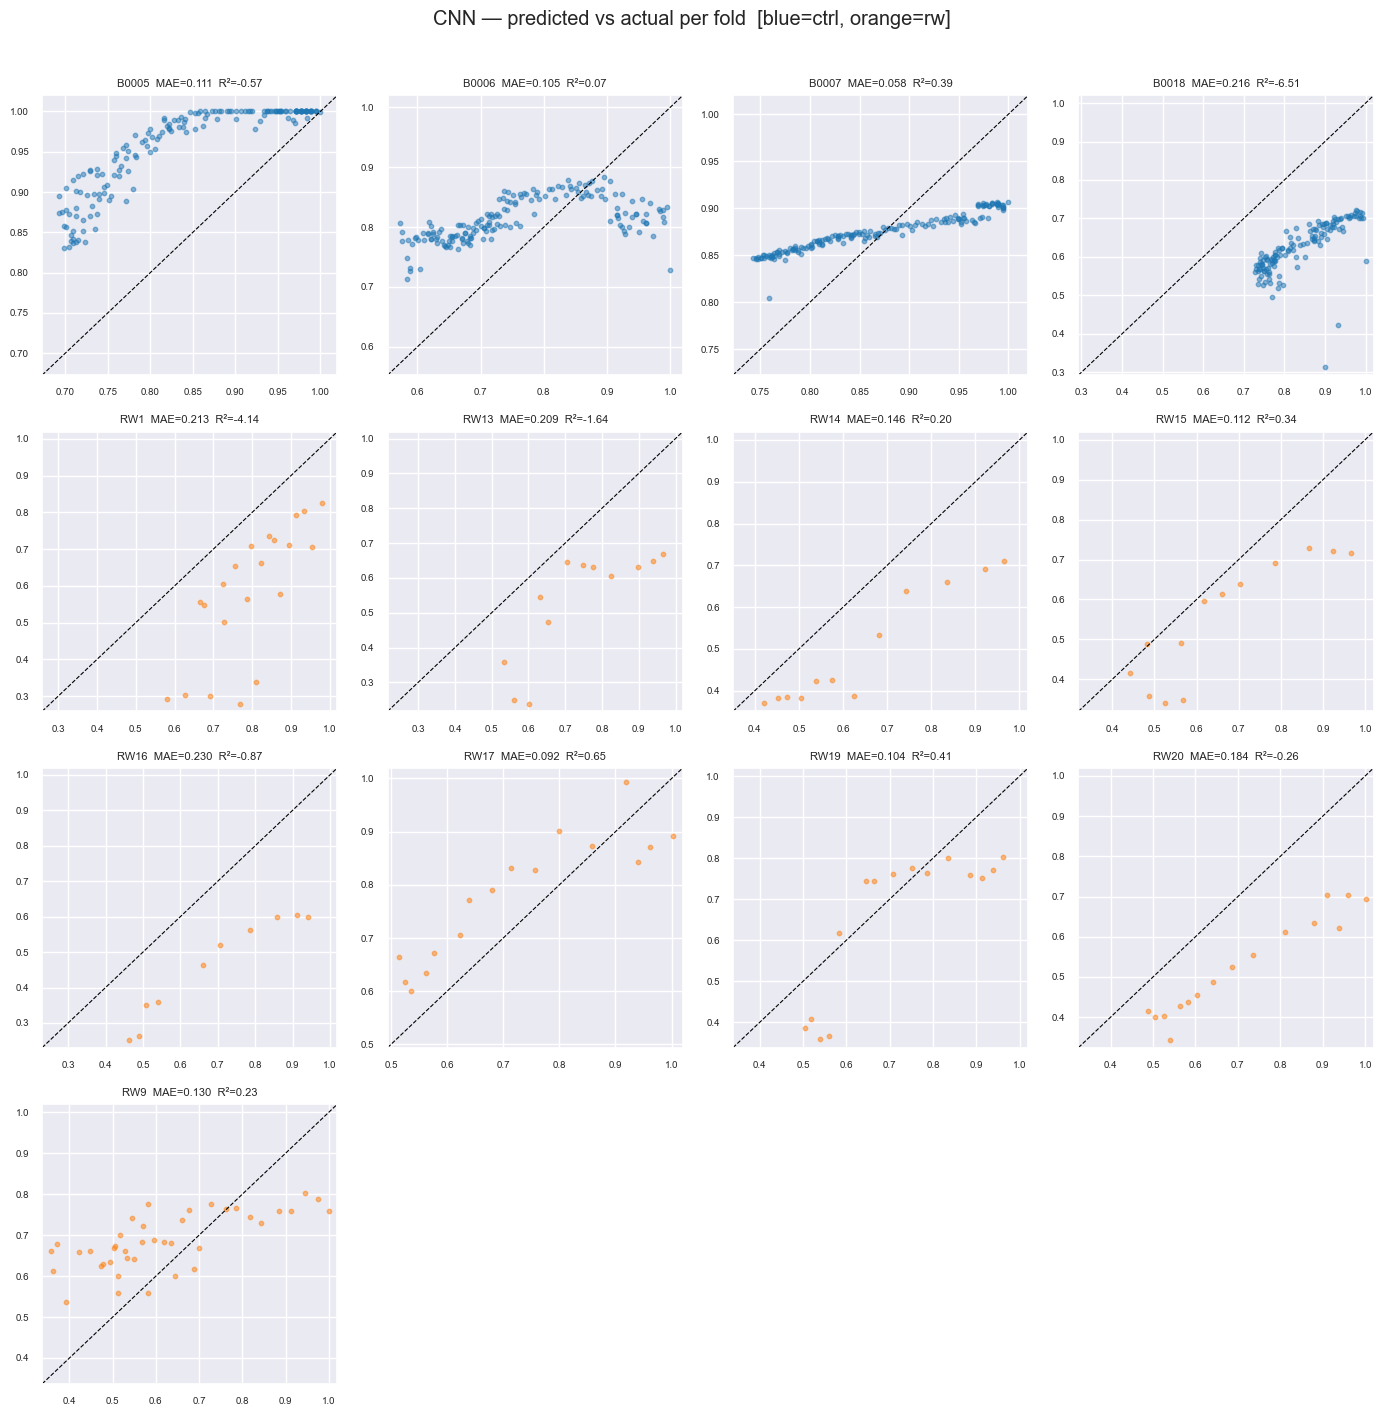


CNN per-fold MAE (worst → best):
  Battery       MAE      R²     n
  ------------------------------------
  RW16       0.2301  -0.872    10  rw
  B0018      0.2163  -6.512   132  ctrl
  RW1        0.2135  -4.137    21  rw
  RW13       0.2087  -1.641    12  rw
  RW20       0.1843  -0.262    16  rw
  RW14       0.1455   0.200    12  rw
  RW9        0.1297   0.230    40  rw
  RW15       0.1120   0.340    13  rw
  B0005      0.1114  -0.569   167  ctrl
  B0006      0.1051   0.069   167  ctrl
  RW19       0.1043   0.411    15  rw
  RW17       0.0924   0.648    16  rw
  B0007      0.0582   0.388   167  ctrl


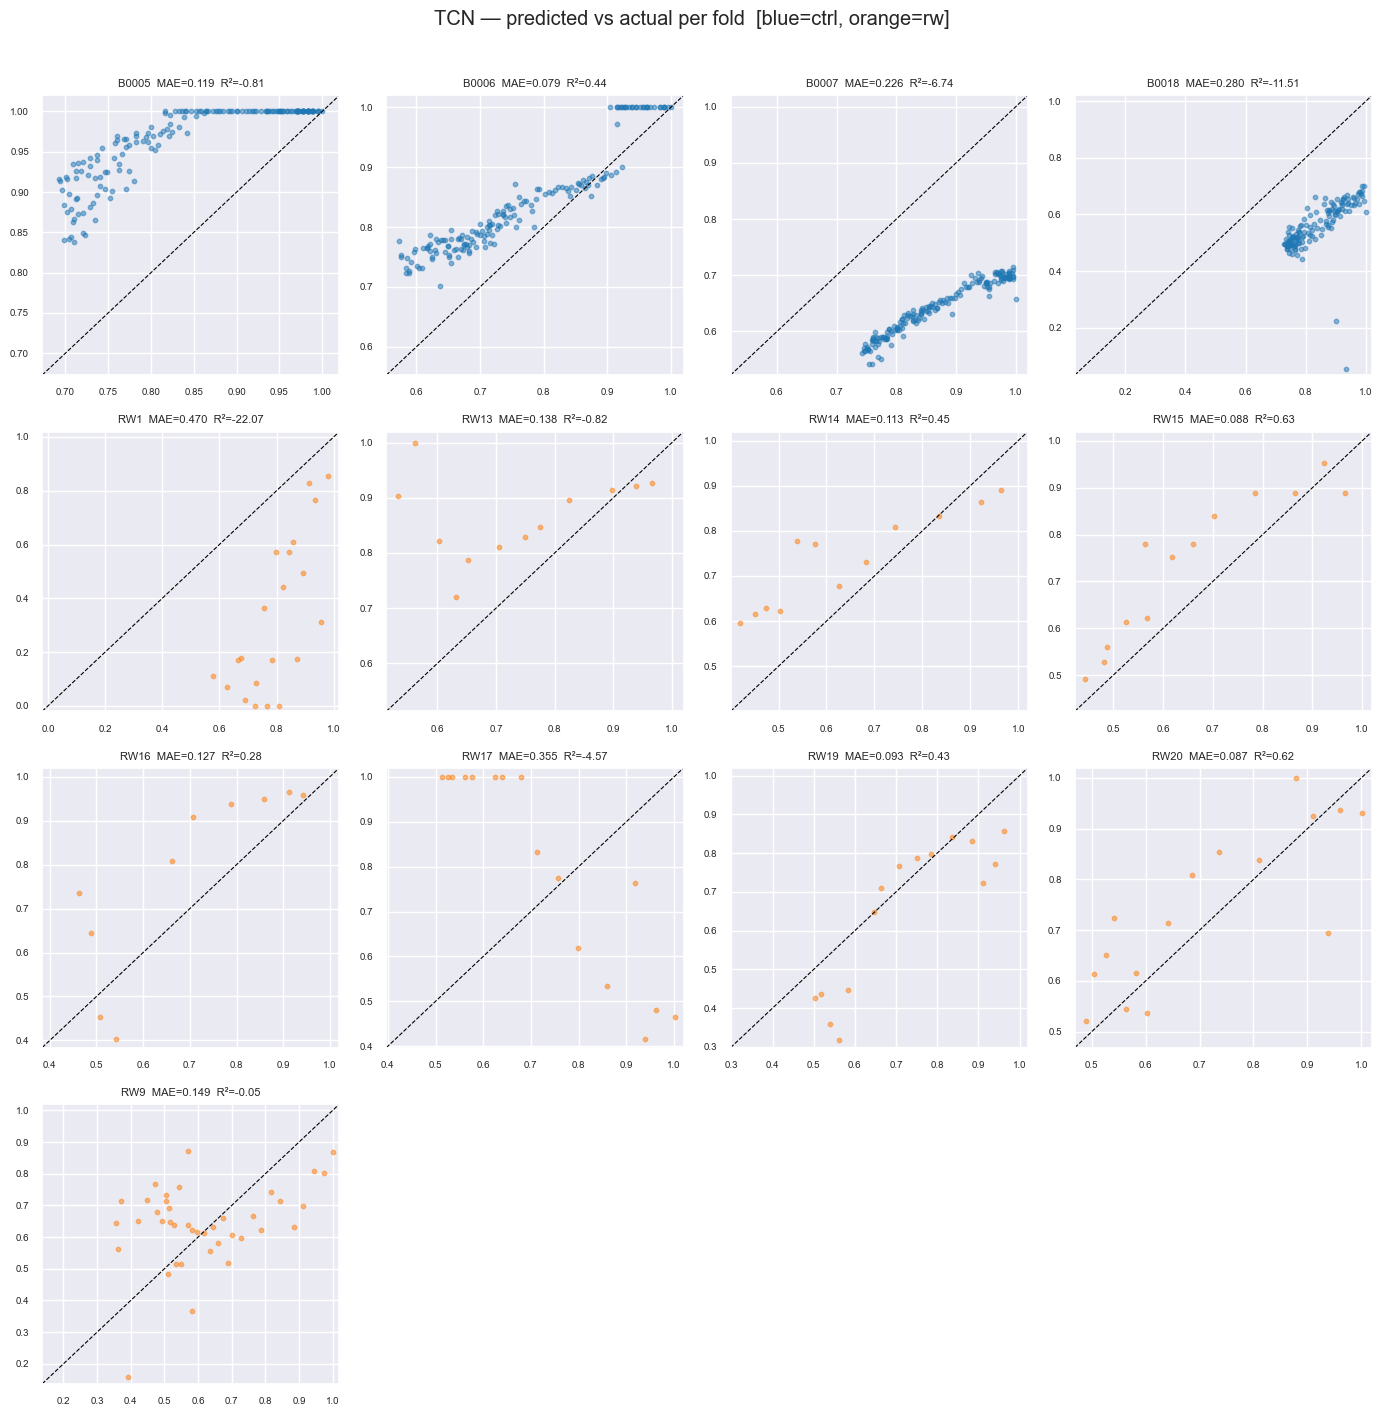


TCN per-fold MAE (worst → best):
  Battery       MAE      R²     n
  ------------------------------------
  RW1        0.4704 -22.066    21  rw
  RW17       0.3552  -4.573    16  rw
  B0018      0.2800 -11.510   132  ctrl
  B0007      0.2264  -6.743   167  ctrl
  RW9        0.1494  -0.049    40  rw
  RW13       0.1378  -0.819    12  rw
  RW16       0.1275   0.279    10  rw
  B0005      0.1191  -0.814   167  ctrl
  RW14       0.1126   0.446    12  rw
  RW19       0.0932   0.426    15  rw
  RW15       0.0881   0.632    13  rw
  RW20       0.0865   0.624    16  rw
  B0006      0.0786   0.440   167  ctrl


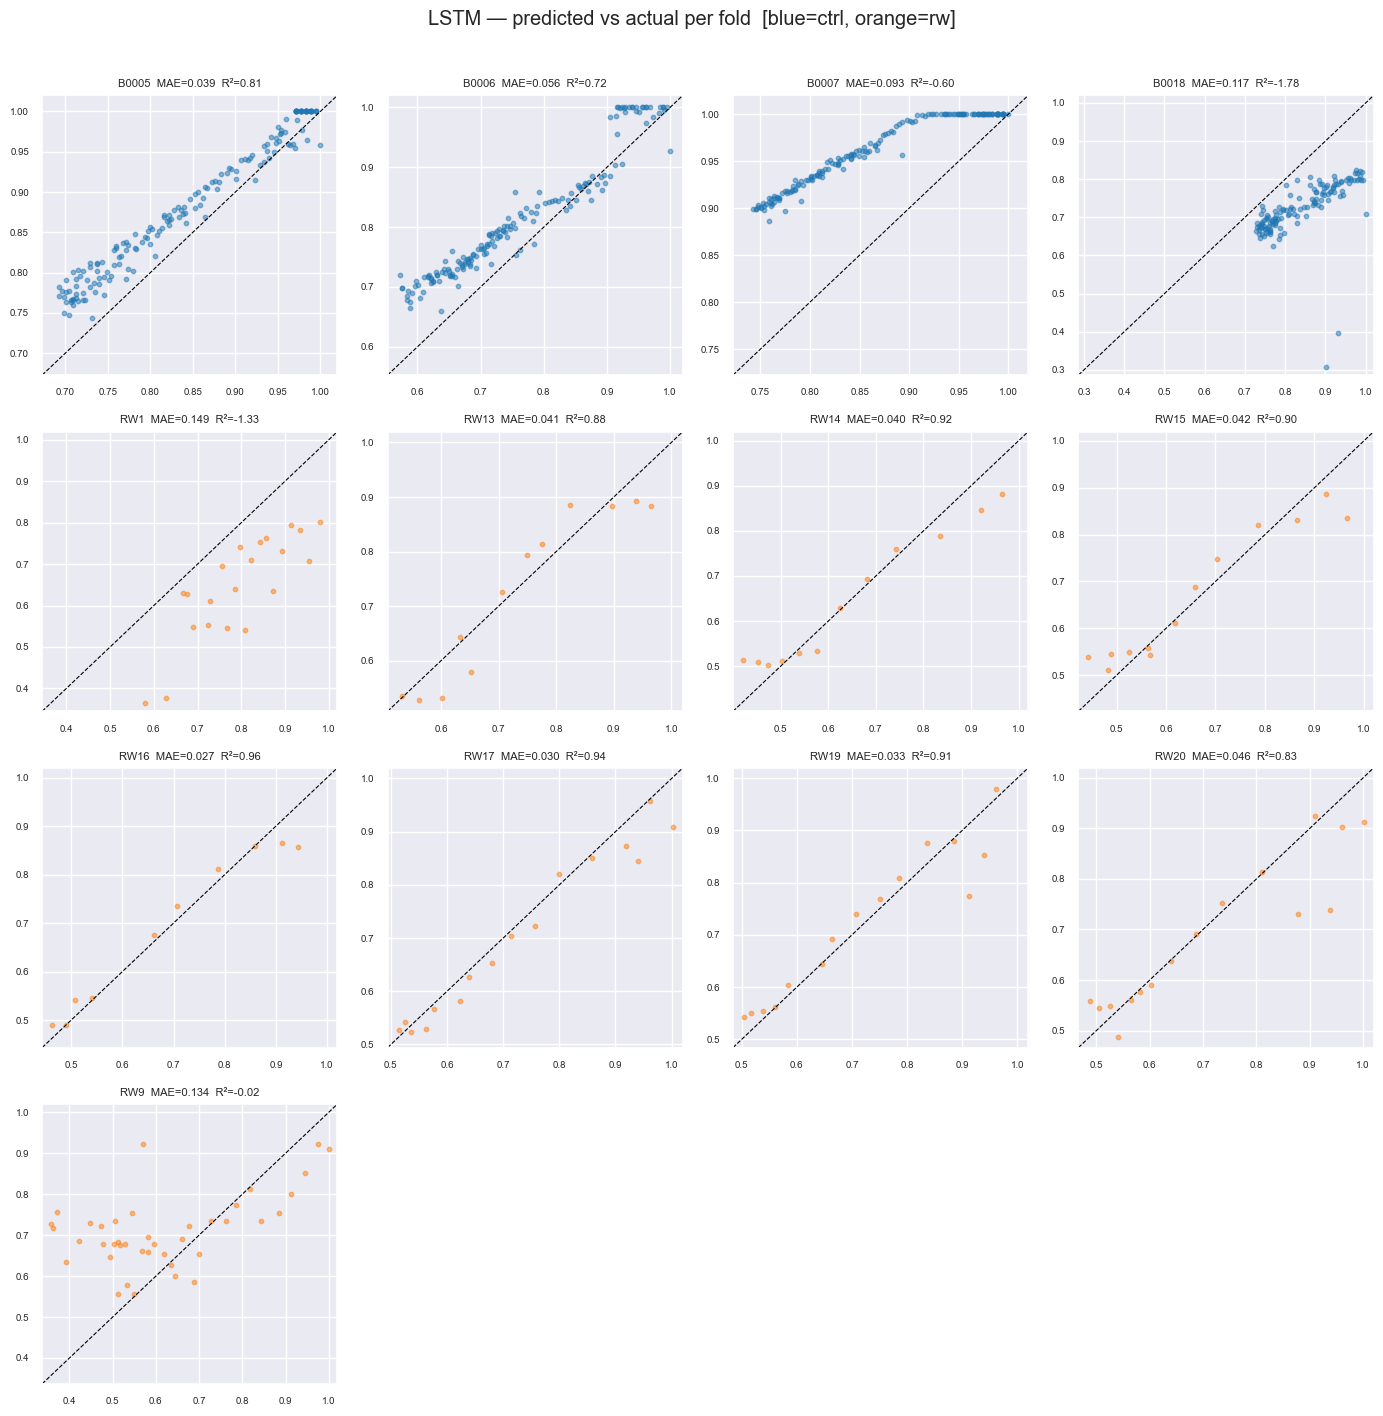


LSTM per-fold MAE (worst → best):
  Battery       MAE      R²     n
  ------------------------------------
  RW1        0.1488  -1.328    21  rw
  RW9        0.1339  -0.023    40  rw
  B0018      0.1166  -1.782   132  ctrl
  B0007      0.0929  -0.604   167  ctrl
  B0006      0.0557   0.725   167  ctrl
  RW20       0.0464   0.829    16  rw
  RW15       0.0424   0.896    13  rw
  RW13       0.0414   0.882    12  rw
  RW14       0.0396   0.921    12  rw
  B0005      0.0389   0.807   167  ctrl
  RW19       0.0330   0.906    15  rw
  RW17       0.0299   0.939    16  rw
  RW16       0.0266   0.957    10  rw


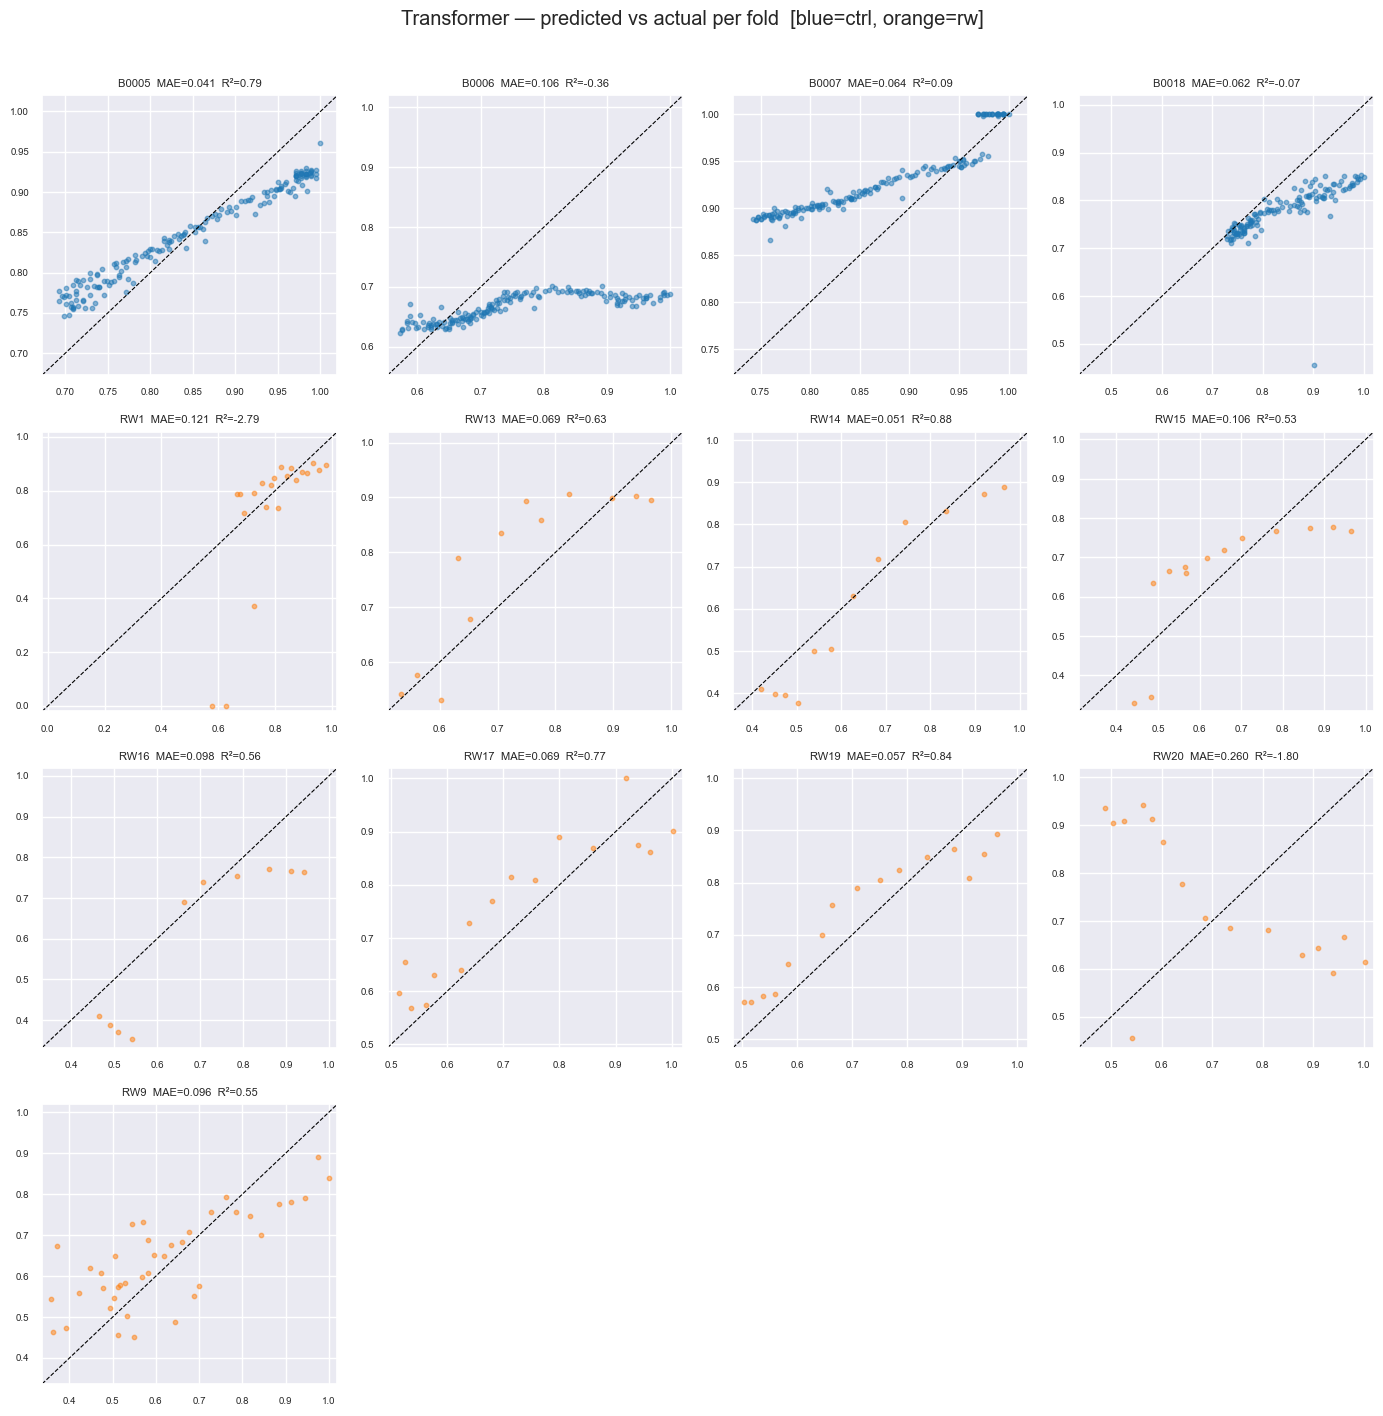


Transformer per-fold MAE (worst → best):
  Battery       MAE      R²     n
  ------------------------------------
  RW20       0.2605  -1.797    16  rw
  RW1        0.1212  -2.790    21  rw
  RW15       0.1060   0.525    13  rw
  B0006      0.1056  -0.360   167  ctrl
  RW16       0.0984   0.562    10  rw
  RW9        0.0960   0.554    40  rw
  RW17       0.0694   0.774    16  rw
  RW13       0.0690   0.626    12  rw
  B0007      0.0640   0.088   167  ctrl
  B0018      0.0624  -0.070   132  ctrl
  RW19       0.0574   0.837    15  rw
  RW14       0.0511   0.880    12  rw
  B0005      0.0408   0.795   167  ctrl


In [11]:
# Per-fold predicted vs actual for each DL architecture
_n_bids = len(all_bids)
_ncols  = min(4, _n_bids)
_nrows  = (_n_bids + _ncols - 1) // _ncols

for arch in TO_EVAL:
    if "Hybrid" in arch:
        continue
    folds = lobo_results[arch]["per_fold"]
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.5 * _ncols, 3.5 * _nrows))
    axes = axes.flatten()
    for i, fold in enumerate(sorted(folds, key=lambda f: f["battery"])):
        ax = axes[i]
        color = "tab:blue" if fold["battery"] in CONTROLLED_BIDS else "tab:orange"
        ax.scatter(fold["y_true_arr"], fold["y_pred_arr"], s=10, alpha=0.5, color=color)
        mn_v = min(fold["y_true_arr"].min(), fold["y_pred_arr"].min()) - 0.02
        ax.plot([mn_v, 1.02], [mn_v, 1.02], "k--", lw=0.8)
        ax.set_xlim(mn_v, 1.02); ax.set_ylim(mn_v, 1.02)
        ax.set_title(f"{fold['battery']}  MAE={fold['mae']:.3f}  R²={fold['r2']:.2f}", fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"{arch} — predicted vs actual per fold  [blue=ctrl, orange=rw]", y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS / f"dl_{arch.lower()}_per_fold.png", dpi=120)
    plt.show()

    print(f"\n{arch} per-fold MAE (worst → best):")
    print(f"  {'Battery':<8} {'MAE':>8} {'R²':>7} {'n':>5}")
    print(f"  {'-'*36}")
    for fold in sorted(folds, key=lambda f: -f["mae"]):
        typ = "ctrl" if fold["battery"] in CONTROLLED_BIDS else "rw"
        print(f"  {fold['battery']:<8} {fold['mae']:>8.4f} {fold['r2']:>7.3f} {len(fold['y_true_arr']):>5}  {typ}")

### Stage-6 baseline — CV-only, time-axis resampling (788 samples)

Results recorded before switching to current-axis resampling. Segmentation fix: `v_cv=4.15`,
DCIR-pulse guard, stub guard `I_MIN=1.0 A`.  `RESAMPLE_AXIS="time"` (uniform over sample index).

#### Aggregate

| Model | MAE ± std | R² ± std | Skill | Mono |
|---|---|---|---|---|
| RF (charge scalars) | 0.0670 ± 0.0509 | 0.379 ± 0.713 | 0.467 | 0.662 |
| LSTM | **0.0730 ± 0.0205** | 0.407 ± 0.642 | 0.424 | 0.684 |

R² std dropped from ~1.26 (pre-Stage-6) to **0.642** — no more catastrophic folds.

**Note:** RF MAE regressed (0.043→0.067) because CV-only tensors make `V_mean/V_mid` near-constant
(~4.20 V); the CC voltage ramp that RF scalars relied on is gone. LSTM is unaffected by this.

#### LSTM per-fold (worst → best)

| Battery | MAE | R² | n | type |
|---|---|---|---|---|
| RW1 | 0.1242 | −0.876 | 21 | rw |
| RW9 | 0.1028 | +0.483 | 40 | rw |
| B0018 | 0.0892 | −1.235 | 132 | ctrl |
| RW13 | 0.0810 | +0.558 | 12 | rw |
| RW15 | 0.0786 | +0.724 | 13 | rw |
| B0005 | 0.0638 | +0.498 | 167 | ctrl |
| B0006 | 0.0629 | +0.671 | 167 | ctrl |
| RW19 | 0.0627 | +0.769 | 15 | rw |
| RW14 | 0.0592 | +0.852 | 12 | rw |
| RW20 | 0.0580 | +0.779 | 16 | rw |
| RW17 | 0.0559 | +0.788 | 16 | rw |
| RW16 | 0.0558 | +0.853 | 10 | rw |
| B0007 | 0.0555 | +0.425 | 167 | ctrl |

#### Shrinkage diagnostic (RW1 & RW9)

| Battery | Model | OLS slope | r(dist,err) | mean error |
|---|---|---|---|---|
| RW1 | RF | −0.468 | −0.627 | −0.072 |
| RW1 | LSTM | **−0.022** | **−0.030** | **−0.124** |
| RW9 | RF | −0.737 | −0.936 | +0.189 |
| RW9 | LSTM | **−0.597** | **−0.893** | +0.045 |

**RW1:** near-zero slope = constant offset, not compression. Diagnosed as nominal-capacity
coverage gap (RW1 baseline 2.00 Ah vs other RW 2.10–2.14 Ah). Not fixable by resampling.

**RW9:** slope −0.60, strong distance correlation = signal-availability compression at high SOH.
LSTM beats RF decisively (0.103 vs 0.205). Target for current-axis resampling.

### Controlled-battery extrapolation vs shrinkage check

For each held-out controlled battery: scatter true SOH (x) vs predicted SOH (y).
Red bands = SOH values the model **never saw in training**.

- Points in red → **extrapolation** (out-of-distribution true SOH)
- Points in white but flat near the grey dashed train-mean line → **shrinkage**

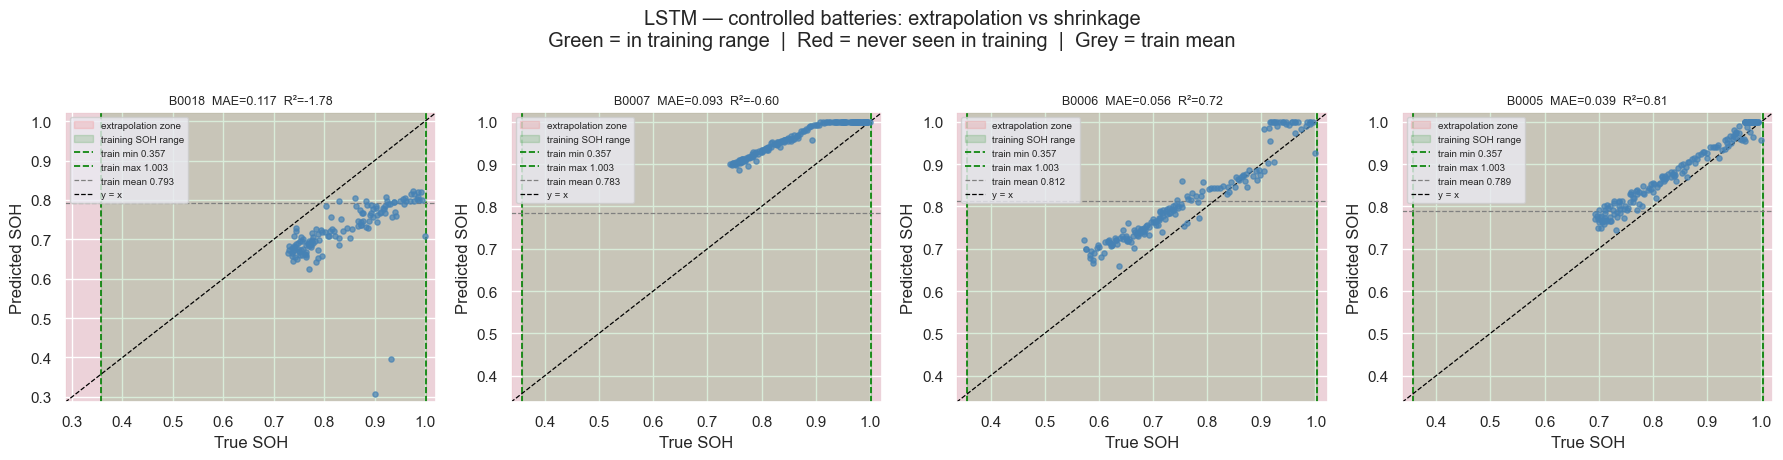

In [12]:
# Extrapolation vs shrinkage diagnostic — held-out controlled batteries
# x = true SOH,  y = predicted SOH
#
# Green band = SOH range SEEN in training  (interpolation zone)
# Red bands  = SOH range NOT seen          (extrapolation zone)
# Grey dashed = training mean              (shrinkage target)
#
# Read:
#   scatter left of red|green boundary  → true SOH below training min
#   scatter right of green|red boundary → true SOH above training max
#   predictions flat near grey line     → shrinkage (model ignores true SOH)

arch_to_check = "LSTM"   # change to "CNN" or "TCN" to compare

ctrl_folds = sorted(
    [f for f in lobo_results[arch_to_check]["per_fold"] if f["battery"] in CONTROLLED_BIDS],
    key=lambda f: -f["mae"],
)

n = len(ctrl_folds)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5), sharey=False)
if n == 1:
    axes = [axes]

for ax, fold in zip(axes, ctrl_folds):
    bid      = fold["battery"]
    is_train = battery_id != bid
    tr_min   = float(soh[is_train].min())
    tr_max   = float(soh[is_train].max())
    tr_mean  = float(soh[is_train].mean())

    y_true = fold["y_true_arr"]
    y_pred = fold["y_pred_arr"]

    # axis limits cover both true and pred, plus the full training range
    lo = min(y_true.min(), y_pred.min(), tr_min) - 0.02
    hi = max(y_true.max(), y_pred.max(), tr_max) + 0.02

    # background: red everywhere, green over the training range
    ax.axvspan(lo,     hi,     alpha=0.10, color="red",   zorder=0, label="extrapolation zone")
    ax.axvspan(tr_min, tr_max, alpha=0.15, color="green", zorder=1, label="training SOH range")

    # boundary lines
    ax.axvline(tr_min, color="green", ls="--", lw=1.2, label=f"train min {tr_min:.3f}")
    ax.axvline(tr_max, color="green", ls="--", lw=1.2, label=f"train max {tr_max:.3f}")

    # shrinkage reference
    ax.axhline(tr_mean, color="grey", ls="--", lw=0.9, label=f"train mean {tr_mean:.3f}")

    # scatter + diagonal
    ax.scatter(y_true, y_pred, s=14, alpha=0.7, zorder=3, color="steelblue")
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.9, label="y = x")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("True SOH")
    ax.set_ylabel("Predicted SOH")
    ax.set_title(f"{bid}  MAE={fold['mae']:.3f}  R²={fold['r2']:.2f}", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")

plt.suptitle(
    f"{arch_to_check} — controlled batteries: extrapolation vs shrinkage\n"
    "Green = in training range  |  Red = never seen in training  |  Grey = train mean",
    y=1.02,
)
plt.tight_layout()
plt.savefig(RESULTS / f"dl_{arch_to_check.lower()}_ctrl_extrap.png", dpi=120)
plt.show()


### RW1 & RW9 outlier investigation

Are these batteries genuinely hard for everyone, or a DL-specific failure?
Each battery is shown twice — RF on the left, best DL arch on the right —
with the same extrapolation/shrinkage overlay.

- If **RF also fails** → inherent outliers (distribution shift or label noise)
- If **RF is fine, DL isn't** → DL-specific issue still to fix

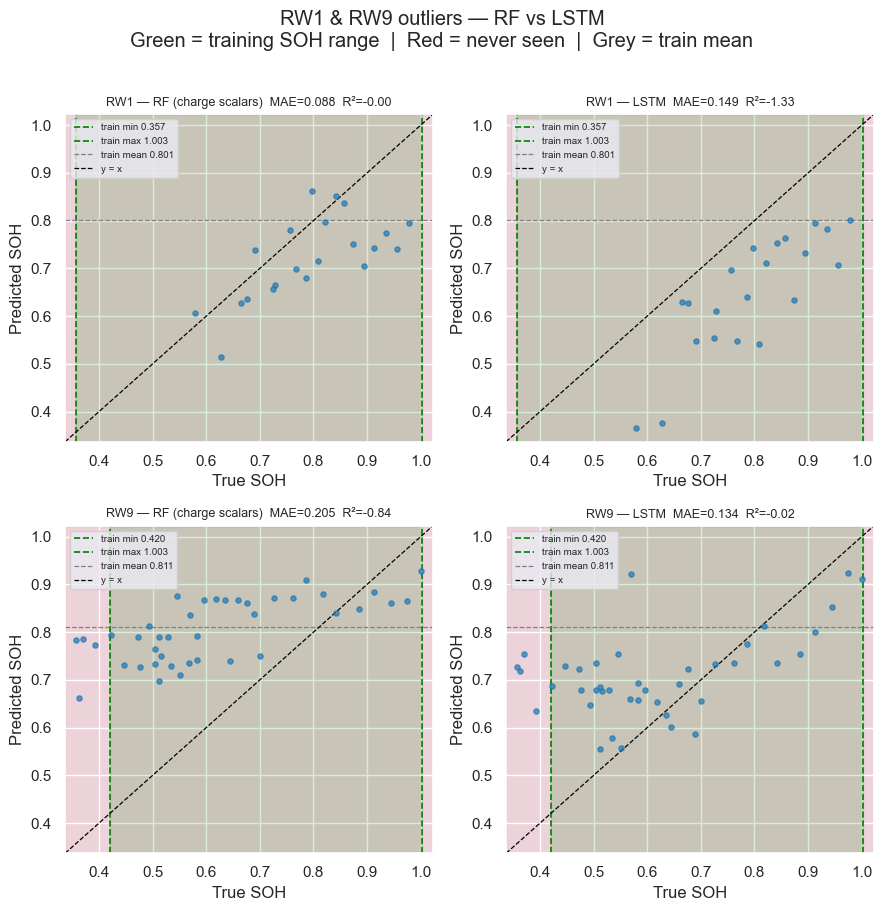

Battery  Model                       MAE      R²     n
----------------------------------------------------
  RW1      RF                       0.0880  -0.001    21
  RW1      LSTM                     0.1488  -1.328    21

  RW9      RF                       0.2052  -0.840    40
  RW9      LSTM                     0.1339  -0.023    40



In [13]:
TARGET_BATTERIES = ["RW1", "RW9"]
arch_rw = "LSTM"   # change to compare another arch

fig, axes = plt.subplots(len(TARGET_BATTERIES), 2,
                         figsize=(9, 4.5 * len(TARGET_BATTERIES)))

for row, bid in enumerate(TARGET_BATTERIES):
    rf_fold = next(f for f in rf_folds if f["battery"] == bid)
    dl_fold = next(f for f in lobo_results[arch_rw]["per_fold"] if f["battery"] == bid)

    is_train = battery_id != bid
    tr_min   = float(soh[is_train].min())
    tr_max   = float(soh[is_train].max())
    tr_mean  = float(soh[is_train].mean())

    for col, (fold, label) in enumerate([(rf_fold, "RF (charge scalars)"),
                                          (dl_fold, arch_rw)]):
        ax = axes[row, col]

        y_true = fold["y_true_arr"]
        y_pred = fold["y_pred_arr"]

        lo = min(y_true.min(), y_pred.min(), tr_min) - 0.02
        hi = max(y_true.max(), y_pred.max(), tr_max) + 0.02

        ax.axvspan(lo,     hi,     alpha=0.10, color="red",   zorder=0)
        ax.axvspan(tr_min, tr_max, alpha=0.15, color="green", zorder=1)
        ax.axvline(tr_min,  color="green", ls="--", lw=1.2, label=f"train min {tr_min:.3f}")
        ax.axvline(tr_max,  color="green", ls="--", lw=1.2, label=f"train max {tr_max:.3f}")
        ax.axhline(tr_mean, color="grey",  ls="--", lw=0.9, label=f"train mean {tr_mean:.3f}")

        ax.scatter(y_true, y_pred, s=14, alpha=0.7, zorder=3)
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.9, label="y = x")

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel("True SOH"); ax.set_ylabel("Predicted SOH")
        ax.set_title(f"{bid} — {label}  MAE={fold['mae']:.3f}  R²={fold['r2']:.2f}",
                     fontsize=9)
        ax.legend(fontsize=7, loc="upper left")

plt.suptitle(
    f"RW1 & RW9 outliers — RF vs {arch_rw}\n"
    "Green = training SOH range  |  Red = never seen  |  Grey = train mean",
    y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS / "rw_outliers_extrap.png", dpi=120)
plt.show()

print(f"{'Battery':<8} {'Model':<22} {'MAE':>8} {'R²':>7} {'n':>5}")
print("-" * 52)
for bid in TARGET_BATTERIES:
    rf_fold = next(f for f in rf_folds if f["battery"] == bid)
    dl_fold = next(f for f in lobo_results[arch_rw]["per_fold"] if f["battery"] == bid)
    for fold, label in [(rf_fold, "RF"), (dl_fold, arch_rw)]:
        print(f"  {bid:<8} {label:<22} {fold['mae']:>8.4f} {fold['r2']:>7.3f} {len(fold['y_true_arr']):>5}")
    print()


### Shrinkage hypothesis: error ∝ distance from training mean?

If the model regresses to the training mean, prediction error should be proportional
to how far the true SOH is from that mean.

**Expected signature of full shrinkage:**
```
error  =  y_pred − y_true  ≈  train_mean − y_true  =  −(y_true − train_mean)
```
→ slope of `error vs (y_true − train_mean)` ≈ **−1**  
→ slope ≈ **0** means no shrinkage (model tracks true SOH regardless of distance from mean)

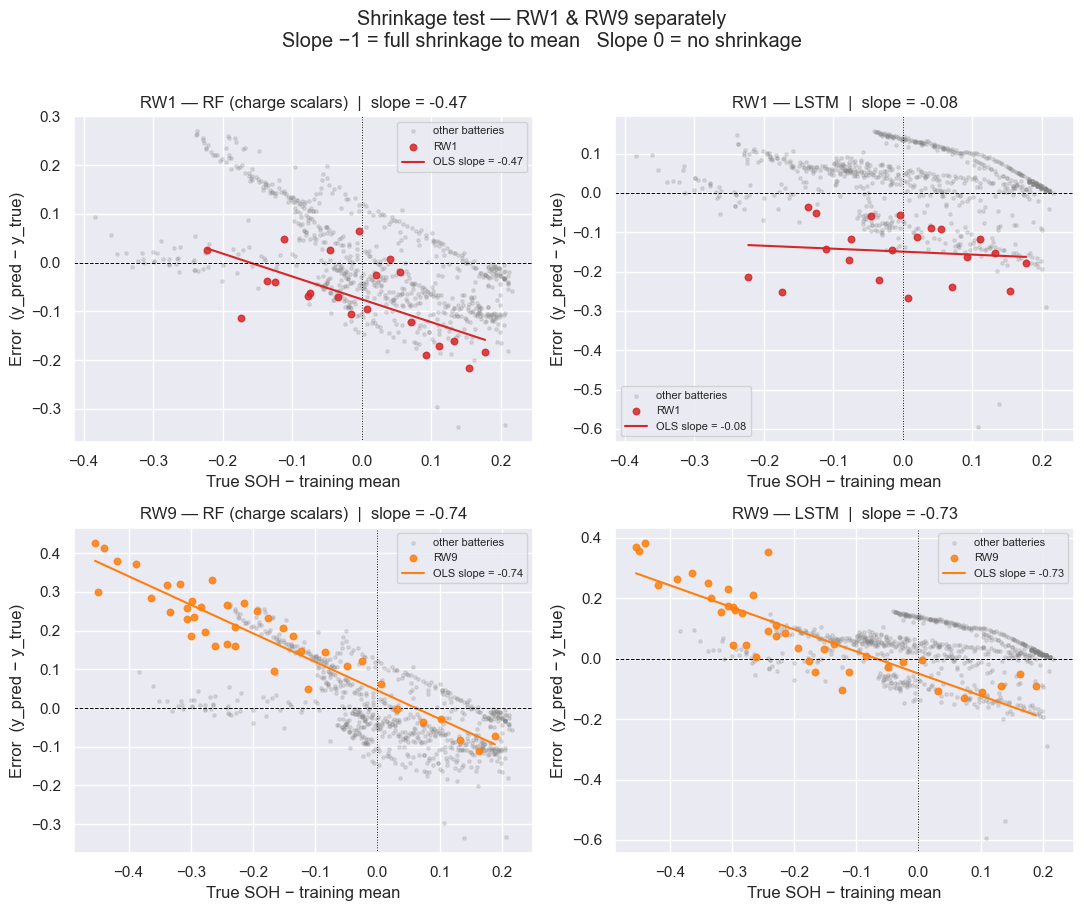

Battery  Model                   OLS slope  r(dist,err)  mean error
--------------------------------------------------------------------
  RW1      RF                         -0.468       -0.627     -0.0717
  RW1      LSTM                       -0.075       -0.116     -0.1488

  RW9      RF                         -0.737       -0.936     +0.1886
  RW9      LSTM                       -0.731       -0.857     +0.0928



In [14]:
arch_shrink = "LSTM"

def collect_errors(fold_list):
    rows = []
    for fold in fold_list:
        bid     = fold["battery"]
        tr_mean = float(soh[battery_id != bid].mean())
        for yt, yp in zip(fold["y_true_arr"], fold["y_pred_arr"]):
            rows.append({
                "battery":        bid,
                "y_true":         float(yt),
                "y_pred":         float(yp),
                "error":          float(yp - yt),
                "dist_from_mean": float(yt - tr_mean),
            })
    return pd.DataFrame(rows)

df_dl = collect_errors(lobo_results[arch_shrink]["per_fold"])
df_rf = collect_errors(rf_folds)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=False, sharex=False)

colors = {"RW1": "tab:red", "RW9": "tab:orange"}

for row, bid in enumerate(TARGET_BATTERIES):
    for col, (df, title) in enumerate([(df_rf, "RF (charge scalars)"),
                                        (df_dl, arch_shrink)]):
        ax = axes[row, col]

        # all other batteries as background
        other = df[~df.battery.isin(TARGET_BATTERIES)]
        ax.scatter(other.dist_from_mean, other.error, s=6, alpha=0.2,
                   color="grey", label="other batteries", zorder=2)

        # this battery highlighted
        sub = df[df.battery == bid]
        ax.scatter(sub.dist_from_mean, sub.error, s=22, alpha=0.85,
                   color=colors[bid], label=bid, zorder=3)

        # OLS on this battery only
        x, y = sub.dist_from_mean.values, sub.error.values
        slope, intercept = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 200)
        ax.plot(xr, slope * xr + intercept, color=colors[bid], lw=1.5,
                label=f"OLS slope = {slope:.2f}")

        ax.axhline(0, color="black", lw=0.7, ls="--")
        ax.axvline(0, color="black", lw=0.7, ls=":")
        ax.set_xlabel("True SOH − training mean")
        ax.set_ylabel("Error  (y_pred − y_true)")
        ax.set_title(f"{bid} — {title}  |  slope = {slope:.2f}")
        ax.legend(fontsize=8)

plt.suptitle(
    "Shrinkage test — RW1 & RW9 separately\n"
    "Slope −1 = full shrinkage to mean   Slope 0 = no shrinkage",
    y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS / "shrinkage_error_vs_dist.png", dpi=120)
plt.show()

print(f"{'Battery':<8} {'Model':<22} {'OLS slope':>10} {'r(dist,err)':>12} {'mean error':>11}")
print("-" * 68)
for bid in TARGET_BATTERIES:
    for df, label in [(df_rf, "RF"), (df_dl, arch_shrink)]:
        sub = df[df.battery == bid]
        x, y = sub.dist_from_mean.values, sub.error.values
        slope = np.polyfit(x, y, 1)[0]
        r     = sub["dist_from_mean"].corr(sub["error"])
        print(f"  {bid:<8} {label:<22} {slope:>10.3f} {r:>+12.3f} {y.mean():>+11.4f}")
    print()


### RW9 charge-onset overlay — signal availability check

Before resampling: are RW9's high-SOH curves visually distinguishable from
training curves at the **same SOH level**?

- **Curves separate at onset** (left edge of each panel) → signal is physically
  present, model just lacks resolution → resampling justified
- **Curves overlap throughout** → signal-availability floor; resampling won't help

RW9 high-SOH range plotted: [0.679, 1.000]
Training curves in same range: 646  (batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20'])
SOH of selected RW9 curves:    [0.6880000233650208, 0.699999988079071, 0.8169999718666077, 0.8429999947547913, 0.8840000033378601, 1.0]
SOH of selected train curves: [0.859000027179718, 0.871999979019165, 0.906000018119812, 0.9210000038146973, 0.9459999799728394, 0.9629999995231628]


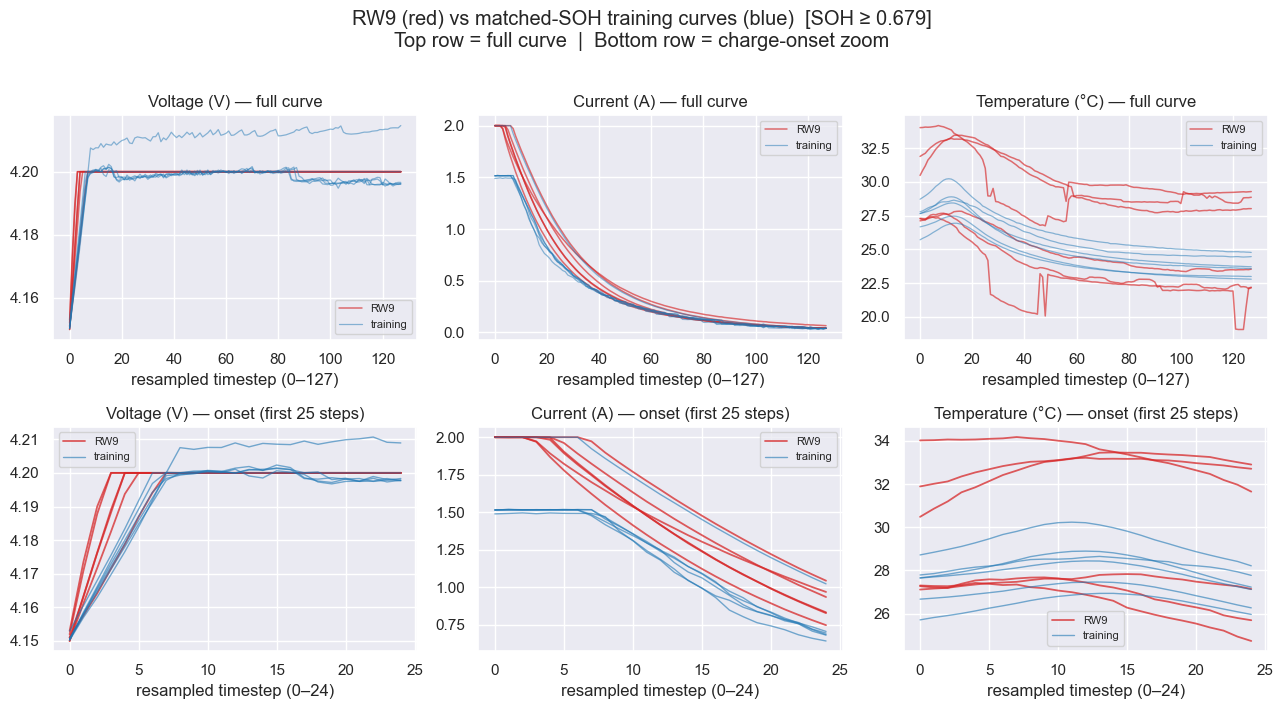

In [15]:
CHECK_BID  = "RW9"   # battery to investigate; swap for RW1 if needed
N_CURVES   = 6       # curves to draw per group
ONSET_ZOOM = 25      # timesteps to show in the zoomed onset panel

is_check  = battery_id == CHECK_BID
is_train  = ~is_check

# Match SOH range: use RW9's top-30% SOH values, find training curves at same level
soh_lo = float(np.quantile(soh[is_check], 0.70))
soh_hi = float(soh[is_check].max())

check_idx = np.where(is_check & (soh >= soh_lo))[0]
train_idx = np.where(is_train & (soh >= soh_lo) & (soh <= soh_hi + 0.02))[0]

rng = np.random.default_rng(42)
c_idx = rng.choice(check_idx, size=min(N_CURVES, len(check_idx)), replace=False)
t_idx = rng.choice(train_idx, size=min(N_CURVES, len(train_idx)), replace=False)

print(f"{CHECK_BID} high-SOH range plotted: [{soh_lo:.3f}, {soh_hi:.3f}]")
print(f"Training curves in same range: {len(train_idx)}  "
      f"(batteries: {sorted(set(battery_id[train_idx]))})")
print(f"SOH of selected {CHECK_BID} curves:    {sorted(soh[c_idx].round(3).tolist())}")
print(f"SOH of selected train curves: {sorted(soh[t_idx].round(3).tolist())}")

ch_names = ["Voltage (V)", "Current (A)", "Temperature (°C)"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ch in range(3):
    # full curve
    ax = axes[0, ch]
    for i, idx in enumerate(c_idx):
        ax.plot(X[idx, :, ch], color="tab:red", alpha=0.65, lw=1.1,
                label=f"{CHECK_BID}" if i == 0 else None)
    for i, idx in enumerate(t_idx):
        ax.plot(X[idx, :, ch], color="tab:blue", alpha=0.50, lw=0.9,
                label="training" if i == 0 else None)
    ax.set_title(f"{ch_names[ch]} — full curve")
    ax.set_xlabel("resampled timestep (0–127)")
    ax.legend(fontsize=8)

    # onset zoom
    ax = axes[1, ch]
    for i, idx in enumerate(c_idx):
        ax.plot(X[idx, :ONSET_ZOOM, ch], color="tab:red", alpha=0.75, lw=1.3,
                label=f"{CHECK_BID}" if i == 0 else None)
    for i, idx in enumerate(t_idx):
        ax.plot(X[idx, :ONSET_ZOOM, ch], color="tab:blue", alpha=0.60, lw=1.0,
                label="training" if i == 0 else None)
    ax.set_title(f"{ch_names[ch]} — onset (first {ONSET_ZOOM} steps)")
    ax.set_xlabel(f"resampled timestep (0–{ONSET_ZOOM-1})")
    ax.legend(fontsize=8)

plt.suptitle(
    f"{CHECK_BID} (red) vs matched-SOH training curves (blue)  "
    f"[SOH ≥ {soh_lo:.3f}]\n"
    "Top row = full curve  |  Bottom row = charge-onset zoom",
    y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS / f"{CHECK_BID.lower()}_curve_overlay.png", dpi=120)
plt.show()


## 7. SOH results table

In [16]:
def fmt(val, std=None, decimals=4):
    if val is None or (isinstance(val, float) and np.isnan(val)): return '—'
    s = f'{val:.{decimals}f}'
    if std is not None and not np.isnan(std):
        s += f' ± {std:.{decimals}f}'
    return s


def res_to_row(res, algo, phase='DL Micro'):
    return {
        'Phase': phase, 'Algorithm': algo,
        'MAE ± std':    fmt(res.get('mae'),          res.get('mae_std')),
        'RMSE':         fmt(res.get('rmse'),         decimals=4),
        'R² ± std':     fmt(res.get('r2'),           res.get('r2_std'), decimals=3),
        'Skill':        fmt(res.get('skill'),         decimals=3),
        'Spearman ρ':   fmt(res.get('spearman'),      decimals=3),
        'Monotonicity': fmt(res.get('monotonicity'),  decimals=3),
        'Cap MAE (Ahr)':fmt(res.get('cap_mae_ahr'),   res.get('cap_mae_ahr_std'), decimals=3),
    }

rows = [res_to_row(rf_soh, 'RF (scalars)', phase='Scalar baseline')]
for arch in ARCH_MAP:
    if arch in lobo_results:
        rows.append(res_to_row(lobo_results[arch], arch))

_hybrid_done = bool(lobo_results_hybrid)
if _hybrid_done:
    for arch, res in lobo_results_hybrid.items():
        rows.append(res_to_row(res, arch, phase='DL Hybrid'))

comparison = pd.DataFrame(rows).set_index(['Phase', 'Algorithm'])
print('=== SOH (capacity_retention) LOBO results ===')
print(comparison.to_string())

_all_lobo = {**lobo_results, **(lobo_results_hybrid if _hybrid_done else {})}
best_arch = min(_all_lobo, key=lambda a: _all_lobo[a]['mae'])
print(f'\nBest arch overall: {best_arch}  (MAE={_all_lobo[best_arch]["mae"]:.4f})')

# Per-battery breakdown -- aggregate hides the story
print('\n=== Per-battery MAE (all evaluated archs) ===')
bids_order = sorted(
    set(f['battery'] for res in _all_lobo.values() for f in res['per_fold']),
    key=lambda b: -next(f['mae'] for f in _all_lobo[best_arch]['per_fold']
                        if f['battery']==b)
)
arch_labels = list(_all_lobo.keys())
header = f"{'Battery':<8} {'type':<5}" + ''.join(f'  {a:>12}' for a in arch_labels)
print(header)
print('-' * len(header))
for bid in bids_order:
    typ = 'ctrl' if bid in CONTROLLED_BIDS else 'rw'
    row = f'{bid:<8} {typ:<5}'
    for arch, res in _all_lobo.items():
        fold = next((f for f in res['per_fold'] if f['battery']==bid), None)
        row += f'  {fold["mae"]:>12.4f}' if fold else f'  {"-":>12}'
    print(row)

print('\nMedian MAE across folds:')
for arch, res in _all_lobo.items():
    maes = [f['mae'] for f in res['per_fold']]
    print(f'  {arch:<16}  median={np.median(maes):.4f}  mean={np.mean(maes):.4f}')

# Save CSV
metrics_rows = [{'phase': 'scalar', 'algorithm': 'RF',
                 **{k: rf_soh.get(k, float('nan')) for k in [
                    'mae','mae_std','rmse','rmse_std','r2','r2_std',
                    'skill','spearman','monotonicity','cap_mae_ahr','cap_mae_ahr_std']}}]
for arch, res in lobo_results.items():
    metrics_rows.append({'phase': 'dl_micro', 'algorithm': arch,
                         **{k: res.get(k, float('nan')) for k in [
                            'mae','mae_std','rmse','rmse_std','r2','r2_std',
                            'skill','spearman','monotonicity','cap_mae_ahr','cap_mae_ahr_std']}})
if _hybrid_done:
    for arch, res in lobo_results_hybrid.items():
        metrics_rows.append({'phase': 'dl_hybrid', 'algorithm': arch,
                             **{k: res.get(k, float('nan')) for k in [
                                'mae','mae_std','rmse','rmse_std','r2','r2_std',
                                'skill','spearman','monotonicity','cap_mae_ahr','cap_mae_ahr_std']}})
pd.DataFrame(metrics_rows).to_csv(RESULTS / 'dl_micro_metrics.csv', index=False)
print('Saved dl_micro_metrics.csv')

=== SOH (capacity_retention) LOBO results ===
                                    MAE ± std    RMSE        R² ± std   Skill Spearman ρ Monotonicity  Cap MAE (Ahr)
Phase           Algorithm                                                                                           
Scalar baseline RF (scalars)  0.0670 ± 0.0509  0.0818   0.379 ± 0.713   0.467      0.874        0.662              —
DL Micro        CNN           0.1470 ± 0.0545  0.1616  -0.900 ± 2.034  -0.144      0.863        0.653  0.226 ± 0.089
                TCN           0.1788 ± 0.1163  0.2017  -3.364 ± 6.454  -0.536      0.639        0.635  0.266 ± 0.188
                LSTM          0.0651 ± 0.0409  0.0796   0.317 ± 0.916   0.447      0.890        0.717  0.099 ± 0.060
                Transformer   0.0925 ± 0.0540  0.1142   0.048 ± 1.079   0.328      0.774        0.604  0.139 ± 0.081
DL Hybrid       Hybrid-LSTM   0.0597 ± 0.0362  0.0763   0.468 ± 0.743   0.530      0.887        0.714  0.088 ± 0.046

Best arch overall

## 8. SOH plots

In [ ]:
# best_arch is set in the results-table cell above (considers pure + hybrid)
print(f"Best DL arch: {best_arch}  (MAE={_all_lobo[best_arch]['mae']:.4f})")

oof_dl = oof_from_lobo(_all_lobo[best_arch])
oof_rf = oof_from_lobo(rf_soh)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, oof, title in zip(axes,
                           [oof_dl, oof_rf],
                           [f"{best_arch} (DL micro)", "RF (scalar baseline)"]):
    ax.scatter(oof["y_true"], oof["y_pred"], s=8, alpha=0.4)
    mn, mx = 0.3, 1.05
    ax.plot([mn, mx], [mn, mx], "k--", lw=0.8)
    ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
    ax.set_xlabel("True SOH"); ax.set_ylabel("Predicted SOH")
    ax.set_title(title)

plt.suptitle("SOH — Predicted vs Actual (LOBO OOF)", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "dl_micro_predicted_vs_actual.png", dpi=120)
plt.show()

In [ ]:
long_bid = max(all_bids, key=lambda b: sum(battery_id == b))
print(f'Trajectory battery: {long_bid}')

fig, ax = plt.subplots(figsize=(9, 4))
mask_b = battery_id == long_bid
cidx_b = cycle_idx[mask_b]
soh_b  = soh[mask_b]
order  = np.argsort(cidx_b)
ax.plot(cidx_b[order], soh_b[order], 'k-', lw=1.5, label='True SOH')

archs_to_plot = [a for a in ARCH_MAP if a in lobo_results]
colors = plt.cm.tab10(np.linspace(0, 0.9, len(archs_to_plot)))
for arch, color in zip(archs_to_plot, colors):
    oof = oof_from_lobo(lobo_results[arch])
    sub = oof[oof.battery_id == long_bid].sort_values('cycle_index')
    ax.plot(sub['cycle_index'], sub['y_pred'], '--', color=color,
            lw=1.2, label=f'{arch} predicted', alpha=0.85)

ax.axhline(0.8, color='grey', ls=':', lw=0.8, label='EOL threshold (80%)')
ax.set_xlabel('Cycle index')
ax.set_ylabel('SOH (capacity retention)')
ax.set_title(f'SOH trajectory -- {long_bid} (held out)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / 'dl_micro_soh_trajectory.png', dpi=120)
plt.show()

## 9. RUL via threshold extrapolation

At each observation point p% of a battery's life, we have the DL-predicted SOH history so
far.  Fit a fade trend to that **past-only** history (no future leakage), extrapolate to the
80% EOL threshold, derive RUL, compare to the RF baseline (rul_frac MAE ≈ 0.032).

**Three fade-trend models compared:**
- Linear: `SOH = a − b·t`  (simplest)
- Exponential: `SOH = a·exp(−b·t)`
- Monotone-constrained (isotonic regression on the history, linear extrapolation)

In [ ]:
from scipy.optimize import curve_fit
from sklearn.isotonic import IsotonicRegression


def rul_from_history(cycles_obs, soh_obs, eol_threshold=0.80):
    """
    Fit three fade-trend models to observed (cycles, SOH) history
    and extrapolate to the EOL threshold.

    Parameters
    ----------
    cycles_obs : 1-D array, observation cycle indices (sorted)
    soh_obs    : 1-D array, observed/estimated SOH values at those cycles
    eol_threshold : float, default 0.80

    Returns dict with keys 'linear', 'exponential', 'monotone':
        each value is the predicted EOL cycle index, or None if extrapolation fails.
    """
    c = np.asarray(cycles_obs, float)
    s = np.asarray(soh_obs, float)
    results = {}

    # --- Linear ---
    try:
        coeffs = np.polyfit(c, s, 1)          # a, b  (s = a*c + b)
        a, b = coeffs
        if a < 0:
            eol_c = (eol_threshold - b) / a
            results["linear"] = float(eol_c)
        else:
            results["linear"] = None
    except Exception:
        results["linear"] = None

    # --- Exponential: s = A * exp(B * c) ---
    try:
        def exp_model(x, A, B):
            return A * np.exp(B * x)
        p0 = [s[0], -0.001]
        popt, _ = curve_fit(exp_model, c, s, p0=p0, maxfev=5000)
        A, B = popt
        if B < 0 and A > 0:
            eol_c = np.log(eol_threshold / A) / B
            results["exponential"] = float(eol_c)
        else:
            results["exponential"] = None
    except Exception:
        results["exponential"] = None

    # --- Monotone-constrained: isotonic fit, then linear extrapolation ---
    try:
        iso = IsotonicRegression(increasing=False)  # SOH is non-increasing
        s_mono = iso.fit_transform(c, s)
        coeffs = np.polyfit(c, s_mono, 1)
        a, b = coeffs
        # Guard: require a meaningful degradation slope (|a| > 1e-5 per cycle).
        # A near-zero slope means the history looks flat — (threshold - b)/a
        # would diverge to ±1e14 and is physically meaningless.
        if a < -1e-5:
            eol_c = (eol_threshold - b) / a
            results["monotone"] = float(eol_c)
        else:
            results["monotone"] = None
    except Exception:
        results["monotone"] = None

    return results


OBS_FRACS = [0.30, 0.50, 0.70]  # observation points: 30%, 50%, 70% of life

def compute_rul_extrapolation(lobo_res, obs_fracs=OBS_FRACS):
    """
    Compute RUL predictions for each battery × observation point × fade-trend.
    Uses LOBO OOF SOH estimates (each battery's SOH predicted while held out).

    LEAKAGE GUARD: at observation point p, only cycles ≤ p% of life are used
    to fit the trend — never future cycles.
    """
    rows = []
    for fold in lobo_res["per_fold"]:
        bid      = fold["battery"]
        cidx_arr = fold["cidx_arr"]
        soh_pred = fold["y_pred_arr"]
        soh_true = fold["y_true_arr"]

        order  = np.argsort(cidx_arr)
        cidx_s = cidx_arr[order]
        pred_s = soh_pred[order]
        true_s = soh_true[order]

        max_cycle = int(cidx_s.max())
        below_eol = cidx_s[true_s <= 0.80]
        true_eol  = int(below_eol[0]) if len(below_eol) > 0 else max_cycle

        for p in obs_fracs:
            obs_cycle = int(max_cycle * p)
            obs_mask  = cidx_s <= obs_cycle
            if obs_mask.sum() < 3:
                continue

            trend_eols = rul_from_history(cidx_s[obs_mask], pred_s[obs_mask])
            true_rul   = max(0, true_eol - obs_cycle)

            for trend_name, pred_eol in trend_eols.items():
                if pred_eol is None:
                    continue
                pred_rul = max(0.0, pred_eol - obs_cycle)
                rows.append({
                    "battery":   bid,
                    "obs_frac":  p,
                    "trend":     trend_name,
                    "true_rul":  true_rul,
                    "pred_rul":  pred_rul,
                    "true_eol":  true_eol,
                    "pred_eol":  pred_eol,
                })
    return pd.DataFrame(rows)


print(f"Computing RUL extrapolation for best arch: {best_arch}")
rul_df = compute_rul_extrapolation(lobo_results[best_arch] if best_arch in lobo_results else lobo_results_hybrid[best_arch])
print(rul_df.groupby(["obs_frac", "trend"]).apply(
    lambda g: mean_absolute_error(g["true_rul"], g["pred_rul"]),
    include_groups=False
).rename("MAE_cycles").round(1).to_string())

In [ ]:
# rul_frac comparison against RF baseline (0.032)
# Normalise: rul_frac = rul_cycles / eol_index (matched per battery)
eol_per_battery = {}
for fold in lobo_results[best_arch]["per_fold"]:
    bid = fold["battery"]
    is_b = battery_id == bid
    eol_per_battery[bid] = int(eol_index[is_b][0])

rul_df["true_rul_frac"] = rul_df.apply(
    lambda r: r["true_rul"] / eol_per_battery.get(r["battery"], 1), axis=1)
rul_df["pred_rul_frac"] = rul_df.apply(
    lambda r: r["pred_rul"] / eol_per_battery.get(r["battery"], 1), axis=1)

summary = rul_df.groupby(["obs_frac", "trend"]).apply(
    lambda g: pd.Series({
        "MAE_cycles": mean_absolute_error(g["true_rul"], g["pred_rul"]),
        "MAE_frac":   mean_absolute_error(g["true_rul_frac"], g["pred_rul_frac"]),
        "n":          len(g),
    }), include_groups=False
).reset_index()

print("=== RUL extrapolation: MAE by observation point × trend ===")
print(f"RF baseline (rul_frac MAE): 0.0317")
print(summary.to_string(index=False))

rul_df.to_csv(RESULTS / "dl_micro_rul_extrapolation.csv", index=False)
print("\nSaved dl_micro_rul_extrapolation.csv")

In [ ]:
# Plot: RUL MAE vs observation point, 3 fade trends
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, ylabel, baseline in [
    (axes[0], "MAE_cycles", "MAE (cycles)", None),
    (axes[1], "MAE_frac",   "MAE (rul_frac)", 0.0317),
]:
    for trend in summary["trend"].unique():
        sub = summary[summary.trend == trend]
        ax.plot(sub["obs_frac"] * 100, sub[metric], "o-", label=trend)
    if baseline is not None:
        ax.axhline(baseline, color="red", ls="--", lw=0.8, label="RF baseline")
    ax.set_xlabel("Observation point (% of life)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"RUL error vs observation point")
    ax.legend(fontsize=8)

plt.suptitle(f"RUL via threshold extrapolation — {best_arch}", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "dl_micro_rul_extrapolation.png", dpi=120)
plt.show()

## 10. SOH-as-feature closing loop

Feed the DL-estimated SOH (out-of-fold, no leakage) back into the macro RF as an extra
feature.  Does the shape-aware health index beat hand-crafted `r_proxy`?

> **Leakage guard #3:** we use the **out-of-fold** DL SOH — each battery's SOH was predicted
> while it was held out, so it is never in-fold.

In [ ]:
# Load macro scalar features (same as nb03/04 Practical phase)
ctrl_csv = pd.read_csv(ROOT / "data" / "processed" / "controlled.csv")
rw_csv   = pd.read_csv(ROOT / "data" / "processed" / "randomized.csv")

shared_cols = [c for c in ctrl_csv.columns if c in rw_csv.columns]
macro_df    = pd.concat([ctrl_csv[shared_cols], rw_csv[shared_cols]], ignore_index=True)

# Base features for Practical phase (no capacity-derived cols, no cycle_norm — same as nb03/04)
MACRO_FEATS = ["r_proxy", "voltage_mean", "temp_mean", "temp_max", "duration_s"]
LEAK_COLS   = {"cycle_norm", "capacity_ahr", "capacity_retention", "cap_delta_from_baseline",
               "battery_id", "cycle_index", "split", "rul_cycles", "rul_frac",
               "rul_censored", "eol_index", "energy_retention", "energy_wh"}

# --- Baseline: RF on macro scalars only ---
def macro_lobo(df, feature_cols, target="rul_frac"):
    all_bids_m = sorted(df["battery_id"].unique())
    folds = []
    for held_out in all_bids_m:
        tr = df[df.battery_id != held_out]
        te = df[df.battery_id == held_out]
        feat_ok = [c for c in feature_cols if c in df.columns]
        scaler  = StandardScaler().fit(tr[feat_ok])
        X_tr = scaler.transform(tr[feat_ok])
        X_te = scaler.transform(te[feat_ok])
        rf   = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        rf.fit(X_tr, tr[target])
        y_pred = rf.predict(X_te).clip(0, 1)
        y_te   = te[target].to_numpy()
        mae    = mean_absolute_error(y_te, y_pred)
        folds.append({"battery": held_out, "mae": mae,
                      "r2": r2_score(y_te, y_pred),
                      "y_true_arr": y_te, "y_pred_arr": y_pred,
                      "cidx_arr": te["cycle_index"].to_numpy()})
    agg = aggregate(folds)
    return agg


print("RF (r_proxy only) on rul_frac ...")
rf_macro = macro_lobo(macro_df, MACRO_FEATS)
print(f"  MAE={rf_macro['mae']:.4f}±{rf_macro['mae_std']:.4f}  R²={rf_macro['r2']:.3f}")


# --- Add OOF DL SOH as extra feature ---
oof_dl_soh = oof_from_lobo(lobo_results[best_arch])
oof_dl_soh = oof_dl_soh.rename(columns={"y_pred": "dl_soh"})

macro_aug = macro_df.merge(
    oof_dl_soh[["battery_id", "cycle_index", "dl_soh"]],
    on=["battery_id", "cycle_index"],
    how="left"
)
macro_aug = macro_aug.dropna(subset=["dl_soh"]).reset_index(drop=True)
print(f"\nMacro DataFrame with DL SOH: {len(macro_aug)} rows (of {len(macro_df)} total)")

print(f"\nRF (r_proxy + dl_soh) on rul_frac ...")
rf_macro_aug = macro_lobo(macro_aug, MACRO_FEATS + ["dl_soh"])
print(f"  MAE={rf_macro_aug['mae']:.4f}±{rf_macro_aug['mae_std']:.4f}  R²={rf_macro_aug['r2']:.3f}")

delta = rf_macro_aug["mae"] - rf_macro['mae']
print(f"\nDelta MAE (dl_soh vs baseline): {delta:+.4f} "
      f"({'improvement' if delta < 0 else 'degradation'})")

## 11. Persist models

In [ ]:
print("Retraining on all 13 batteries and persisting...")

X_all_scaled = per_sample_scale(X)

rng_split = np.random.default_rng(42)
val_idx   = rng_split.choice(len(X_all_scaled), size=int(0.15 * len(X_all_scaled)), replace=False)
tr_idx    = np.setdiff1d(np.arange(len(X_all_scaled)), val_idx)

X_tr_all = X_all_scaled[tr_idx]; y_tr_all = soh[tr_idx]; m_tr_all = mask[tr_idx]
X_va_all = X_all_scaled[val_idx]; y_va_all = soh[val_idx]; m_va_all = mask[val_idx]

for arch in ARCH_MAP:
    torch.manual_seed(42)
    model = ARCH_MAP[arch]().to(device)
    model, _, _, final_ep = train_model(
        model, X_tr_all, m_tr_all, y_tr_all,
        X_va_all, m_va_all, y_va_all,
        device,
        epochs=300,
        patience=TIER1_PATIENCE,
        scheduler="cosine",
        augment_fn=make_jitter_fn(SIGMA_JITTER),
    )
    fname = MODELS / f"practical_soh_{arch.lower()}.pt"
    torch.save({
        "state_dict":   {k: v.cpu() for k, v in model.state_dict().items()},
        "arch":         arch,
        "n_features":   C,
        "channels":     ["V", "I", "T"],
        "n_points":     N,
        "v_lo":         3.8,
        "i_cut":        0.04,
        "phase":        "practical",
        "task":         "soh",
        "norm":         "per_sample_zscore",
    }, fname)
    print(f"  {arch}: saved to {fname}  (ep={final_ep})")

print("\nAll models persisted.")

## 12. Summary

In [ ]:
print('=' * 60)
print('NOTEBOOK 06 -- WITHIN-CYCLE DL SOH ESTIMATION -- SUMMARY')
print('=' * 60)
print()
print(f"{'Model':<18}  {'Params':>7}  {'MAE':>8}  {'R²':>8}  {'Skill':>7}  {'Mono':>7}")
print('-' * 62)
print(f"{'RF (scalar)':<18}  {'--':>7}  {rf_soh['mae']:>8.4f}  {rf_soh['r2']:>8.3f}  "
      f"{rf_soh['skill']:>7.3f}  {rf_soh['monotonicity']:>7.3f}")
for arch in ARCH_MAP:
    if arch not in lobo_results: continue
    r = lobo_results[arch]
    n_params = sum(p.numel() for p in ARCH_MAP[arch]().parameters())
    marker = ' <- best' if arch == best_arch else ''
    print(f'{arch:<18}  {n_params:>7,}  {r["mae"]:>8.4f}  {r["r2"]:>8.3f}  '
          f'{r["skill"]:>7.3f}  {r["monotonicity"]:>7.3f}{marker}')
if _hybrid_done:
    print()
    for arch, r in lobo_results_hybrid.items():
        n_params = sum(p.numel() for p in ARCH_MAP_HYBRID[arch]().parameters())
        marker = ' <- best' if arch == best_arch else ''
        print(f'{arch:<18}  {n_params:>7,}  {r["mae"]:>8.4f}  {r["r2"]:>8.3f}  '
              f'{r["skill"]:>7.3f}  {r["monotonicity"]:>7.3f}{marker}')
print()
print(f'Best overall: {best_arch}  (MAE={_all_lobo[best_arch]["mae"]:.4f})')
print()
print(f'--- RUL extrapolation ({best_arch}, 50% obs point) ---')
sub50 = summary[summary.obs_frac == 0.50]
print(sub50[['trend', 'MAE_cycles', 'MAE_frac']].to_string(index=False))
print('RF baseline rul_frac MAE: 0.0317')
print()
print('--- Closing loop: DL SOH as feature in macro RF ---')
print(f'  r_proxy only:       MAE={rf_macro["mae"]:.4f}')
print(f'  r_proxy + dl_soh:   MAE={rf_macro_aug["mae"]:.4f}  '
      f'(delta={rf_macro_aug["mae"]-rf_macro["mae"]:+.4f})')